In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 42.2 MB/s eta 0:00:00
✓ Device: cuda
✓ All imports successful
✓ Configuration set
STEP 1 — Loading & Preparing Data
Loaded: 3,205 rows × 67 columns

Class distribution:
        Mild: 1,297 (40.5%)
    Moderate: 442 (13.8%)
      Severe: 1,466 (45.7%)

Imputing (KNN)... done
✓ Class weights: {'Mild': np.float64(0.82), 'Moderate': np.float64(2.42), 'Severe': np.float64(0.73)}
✓ Train: 2,564  Test: 641
✓ Features: 29

STEP 2 — Non-DL Models (Cross-Validation)

Running 5-fold CV...

  Logistic Regression... AUC=0.721±0.013  F1=0.602
  Random Forest... AUC=0.743±0.008  F1=0.629
  XGBoost... AUC=0.746±0.004  F1=0.631

Tuning Non-DL models (Optuna, 50 trials each)...

  [1/3] Logistic Regression (grid over C)...
    ✓ Best C=0.1  AUC=0.7211

  [2/3] Random Forest (50 trials)...


  0%|          | 0/50 [00:00<?, ?it/s]

    ✓ Best RF AUC: 0.7550
      Params: {'n_estimators': 558, 'max_depth': 9, 'min_samples_split': 16, 'min_samples_leaf': 6, 'max_features': 'log2'}

  [3/3] XGBoost (50 trials)...


  0%|          | 0/50 [00:00<?, ?it/s]

    ✓ Best XGB AUC: 0.7603
      Params: {'n_estimators': 505, 'learning_rate': 0.012473041770165595, 'max_depth': 10, 'subsample': 0.5216212762777431, 'colsample_bytree': 0.9094577976752624, 'reg_alpha': 0.013504002797384038, 'reg_lambda': 0.061999873951121415, 'min_child_weight': 1}

Training final non-DL models with tuned hyperparameters...
  ✓ Logistic Regression
  ✓ Random Forest
  ✓ XGBoost

Non-DL tuning complete.
  LR  best C:           0.1
  RF  best n_estimators: 558, max_depth: 9
  XGB best lr:           0.0125, max_depth: 10, n_estimators: 505

STEP 3 — DL Model Definitions
✓ MLP Classifier defined
✓ 1D CNN Classifier defined
✓ TabNet Classifier will be initialised per fold

STEP 4 — DL Models (Cross-Validation)

  MLP:
    Fold 1: AUC=0.749  F1=0.577
    Fold 2: AUC=0.786  F1=0.602
    Fold 3: AUC=0.773  F1=0.574
    Fold 4: AUC=0.770  F1=0.597
    Fold 5: AUC=0.797  F1=0.602
  → Mean: AUC=0.775±0.016  F1=0.591±0.012

  1D CNN:
    Fold 1: AUC=0.770  F1=0.577
    Fold 2: A

...

  ✓ Best MLP F1: 0.6170
    Params: {'h1': 256, 'h2': 64, 'h3': 32, 'dropout': 0.36772692744903723, 'lr': 0.00020591233059887314}

[2/3] Tuning 1D CNN...


  0%|          | 0/50 [00:00<?, ?it/s]

  ✓ Best CNN F1: 0.6350
    Params: {'dropout': 0.4042079223928574, 'lr': 0.0010688969654884983, 'filters1': 64, 'filters2': 256, 'dense': 256}

[3/3] Tuning TabNet...


  0%|          | 0/50 [00:00<?, ?it/s]


Early stopping occurred at epoch 44 with best_epoch = 34 and best_val_0_accuracy = 0.66667

Early stopping occurred at epoch 47 with best_epoch = 37 and best_val_0_accuracy = 0.65692

Early stopping occurred at epoch 37 with best_epoch = 27 and best_val_0_accuracy = 0.62378

Early stopping occurred at epoch 29 with best_epoch = 19 and best_val_0_accuracy = 0.62768

Early stopping occurred at epoch 34 with best_epoch = 24 and best_val_0_accuracy = 0.55945

Early stopping occurred at epoch 48 with best_epoch = 38 and best_val_0_accuracy = 0.63938

Early stopping occurred at epoch 24 with best_epoch = 14 and best_val_0_accuracy = 0.65692

Early stopping occurred at epoch 18 with best_epoch = 8 and best_val_0_accuracy = 0.65107

Early stopping occurred at epoch 20 with best_epoch = 10 and best_val_0_accuracy = 0.63353

Early stopping occurred at epoch 29 with best_epoch = 19 and best_val_0_accuracy = 0.66667

Early stopping occurred at epoch 29 with best_epoch = 19 and best_val_0_accuracy

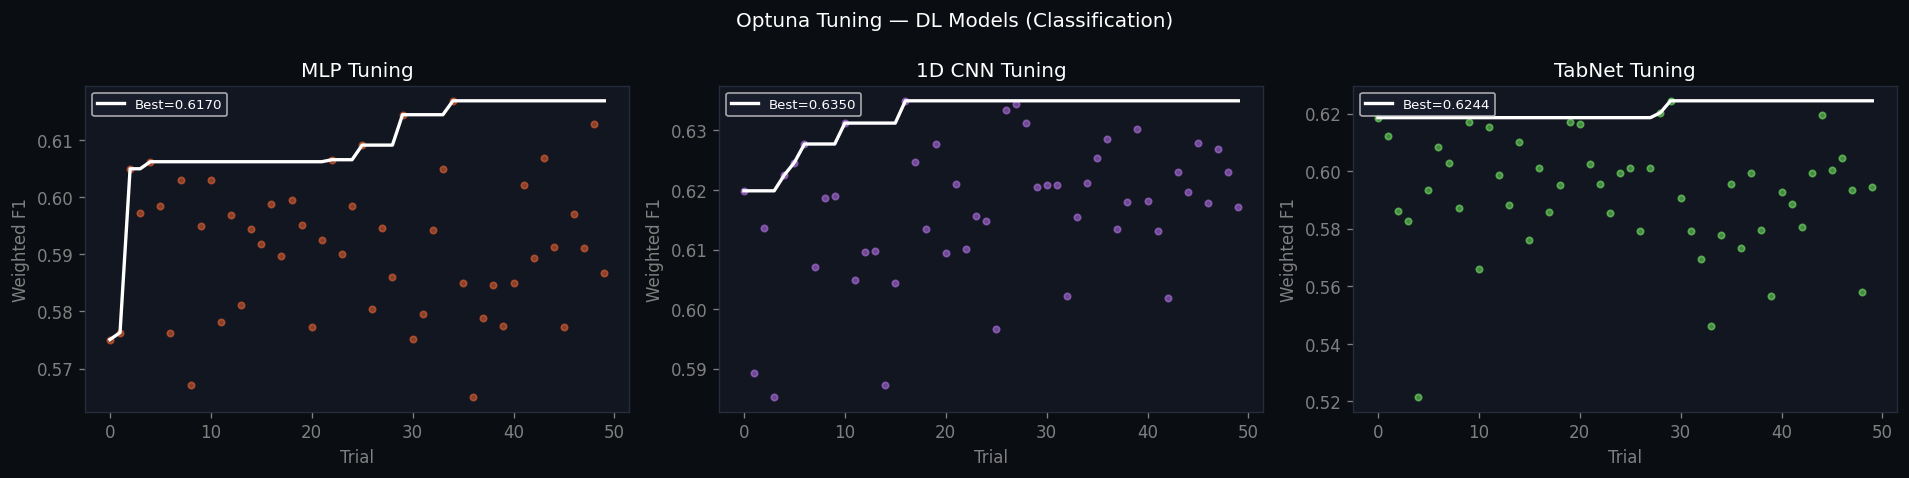


Tuning Summary:
  MLP    best F1: 0.6170  → hidden=[256, 64, 32], dropout=0.368, lr=0.00021
  CNN    best F1: 0.6350  → filters=(64,256), dense=256, dropout=0.404
  TabNet best F1: 0.6244  → n_d=16, n_steps=7, gamma=1.258

STEP 6 — Final Test Set Evaluation (Tuned Models)

Training tuned MLP... done
Training tuned CNN... done
Training tuned TabNet... 
Early stopping occurred at epoch 58 with best_epoch = 43 and best_val_0_accuracy = 0.64119
done

Model                     AUC-ROC   Accuracy         F1  Type
────────────────────────────────────────────────────────────
Logistic Regression        0.7903     0.6022     0.6229  Non-DL
Random Forest              0.8044     0.6583     0.6362  Non-DL
XGBoost                    0.8106     0.6911     0.6429  Non-DL
MLP                        0.7995     0.6349     0.6388  DL
1D CNN                     0.7847     0.6490     0.6191  DL
TabNet                     0.7404     0.6412     0.5940  DL

✓ Best model: XGBoost (AUC=0.8106)

STEP 7 — Generat

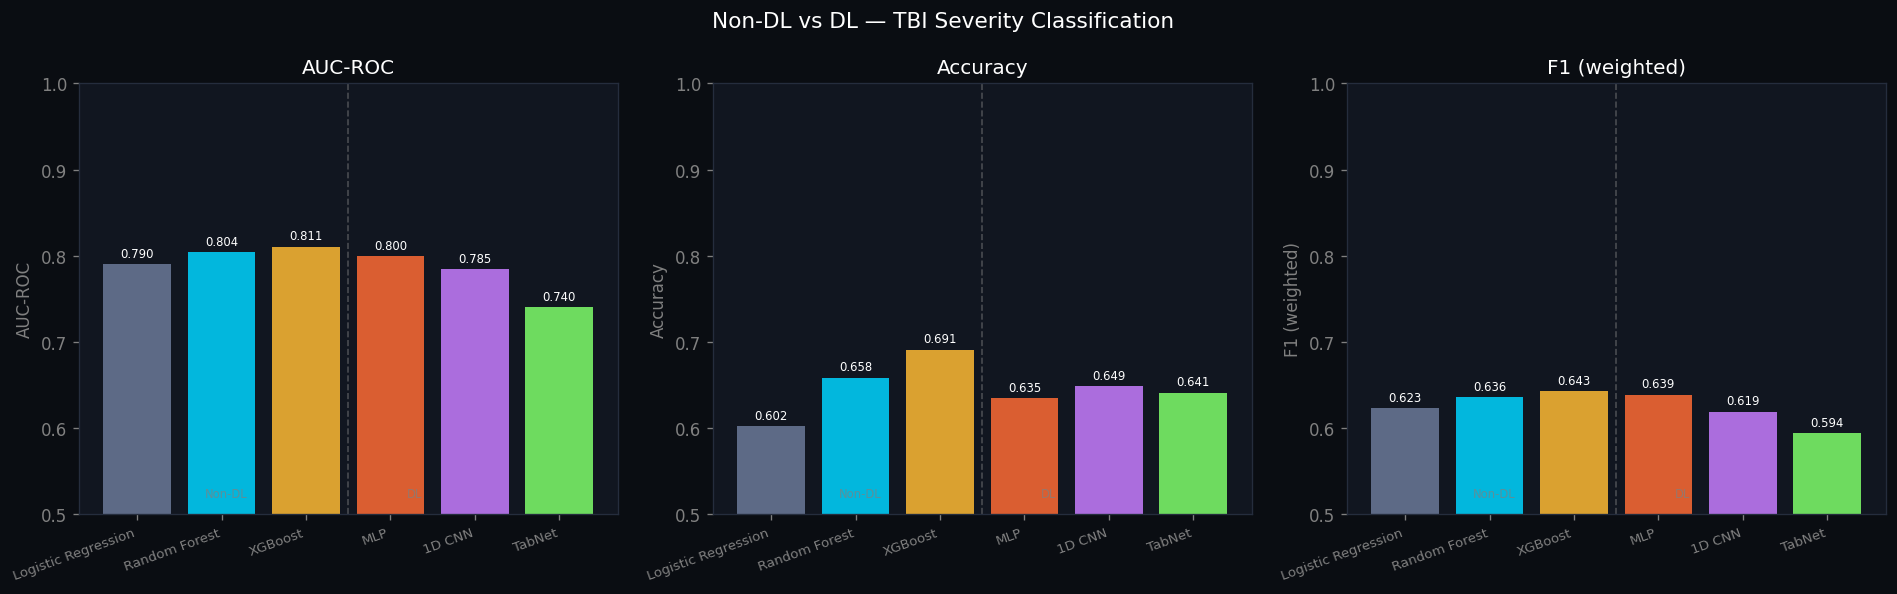


────────────────────────────────────────────────────────────
  CV AUC Comparison
────────────────────────────────────────────────────────────


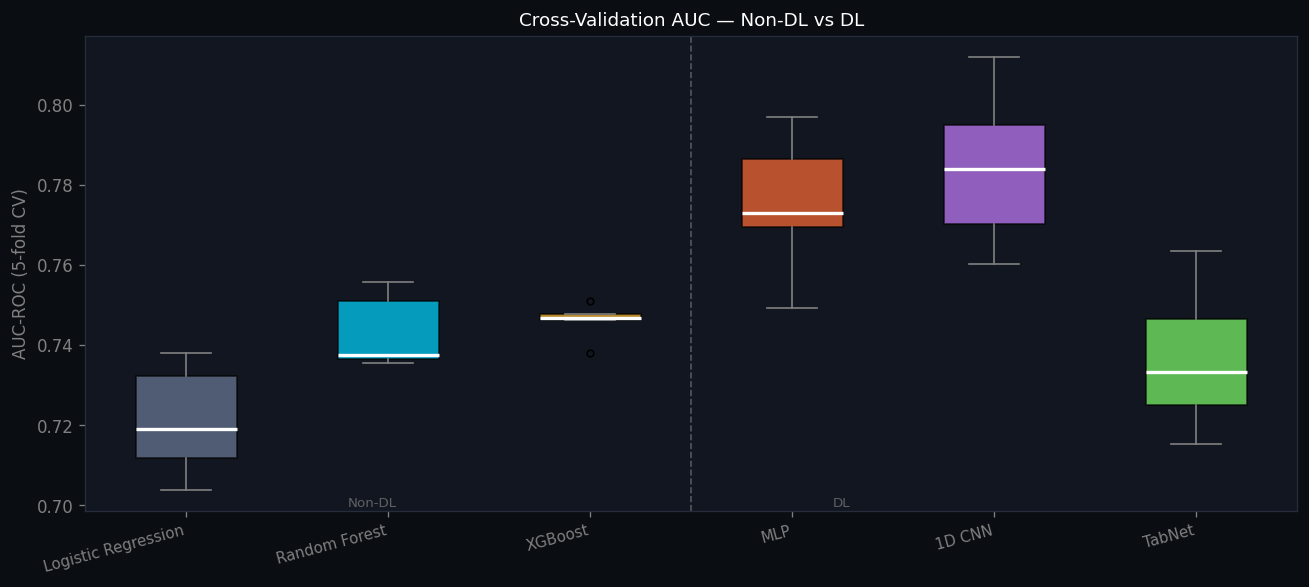


────────────────────────────────────────────────────────────
  Confusion Matrices
────────────────────────────────────────────────────────────


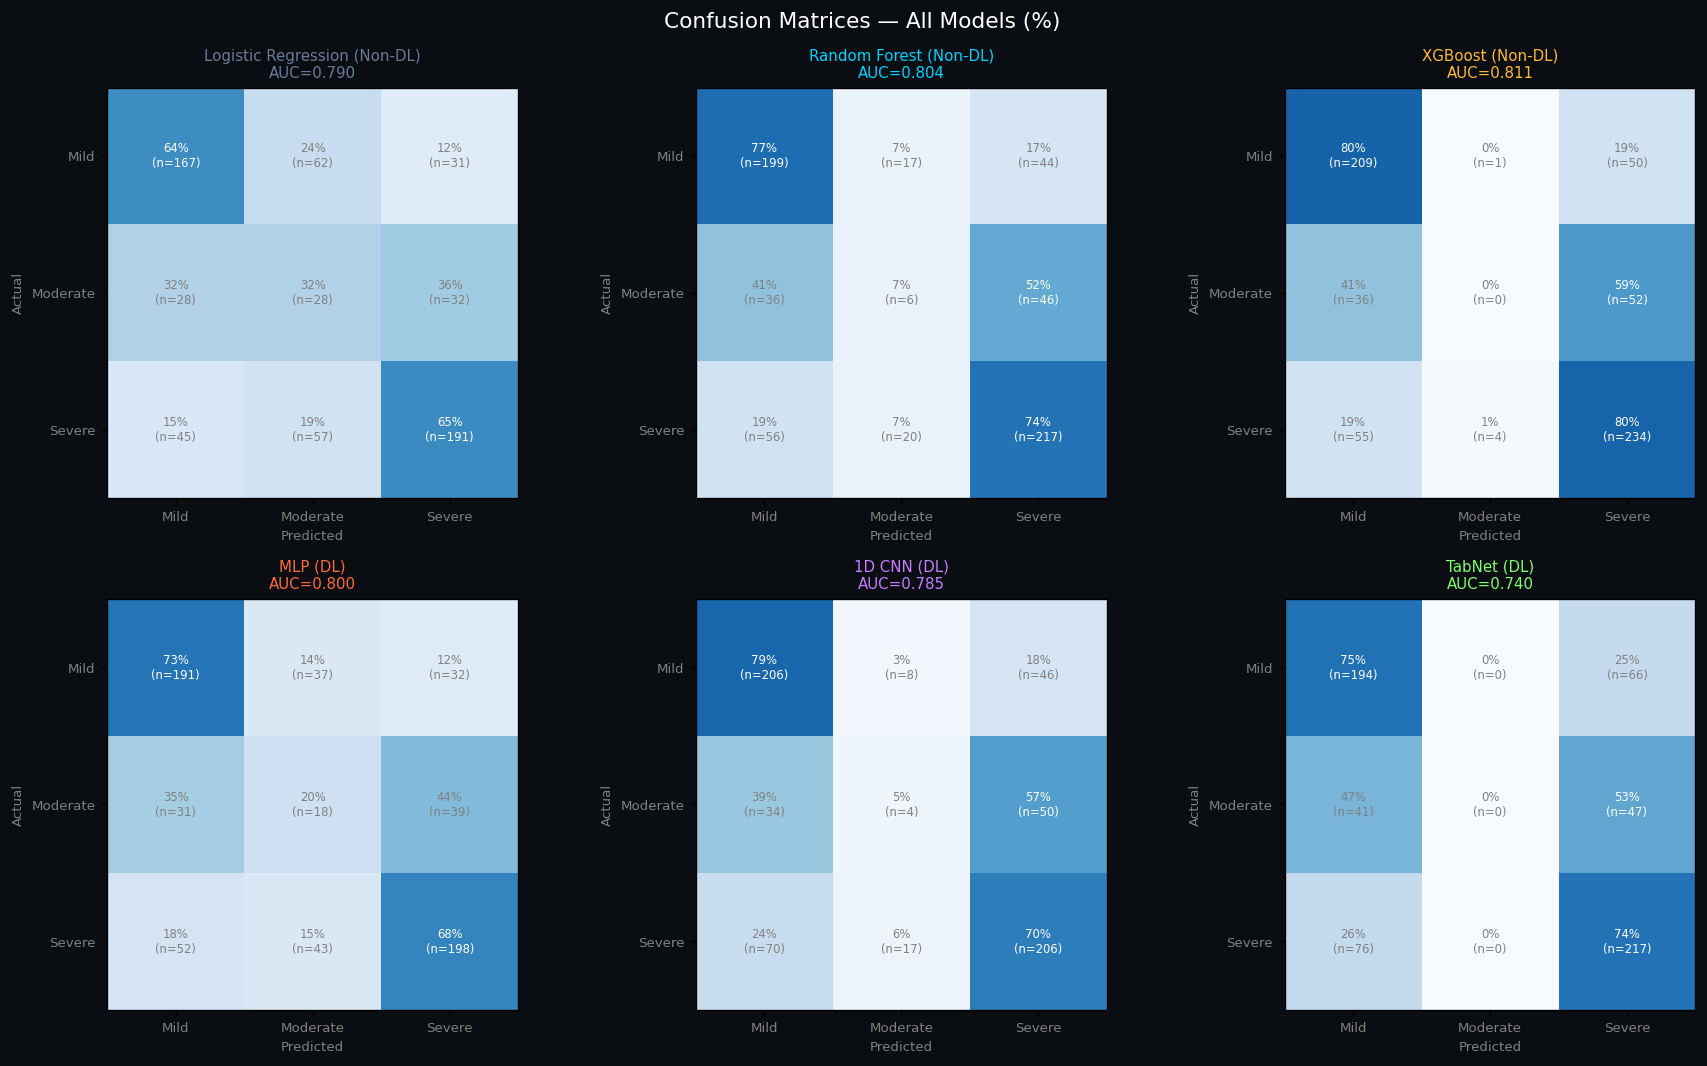


────────────────────────────────────────────────────────────
  Per-Class F1
────────────────────────────────────────────────────────────


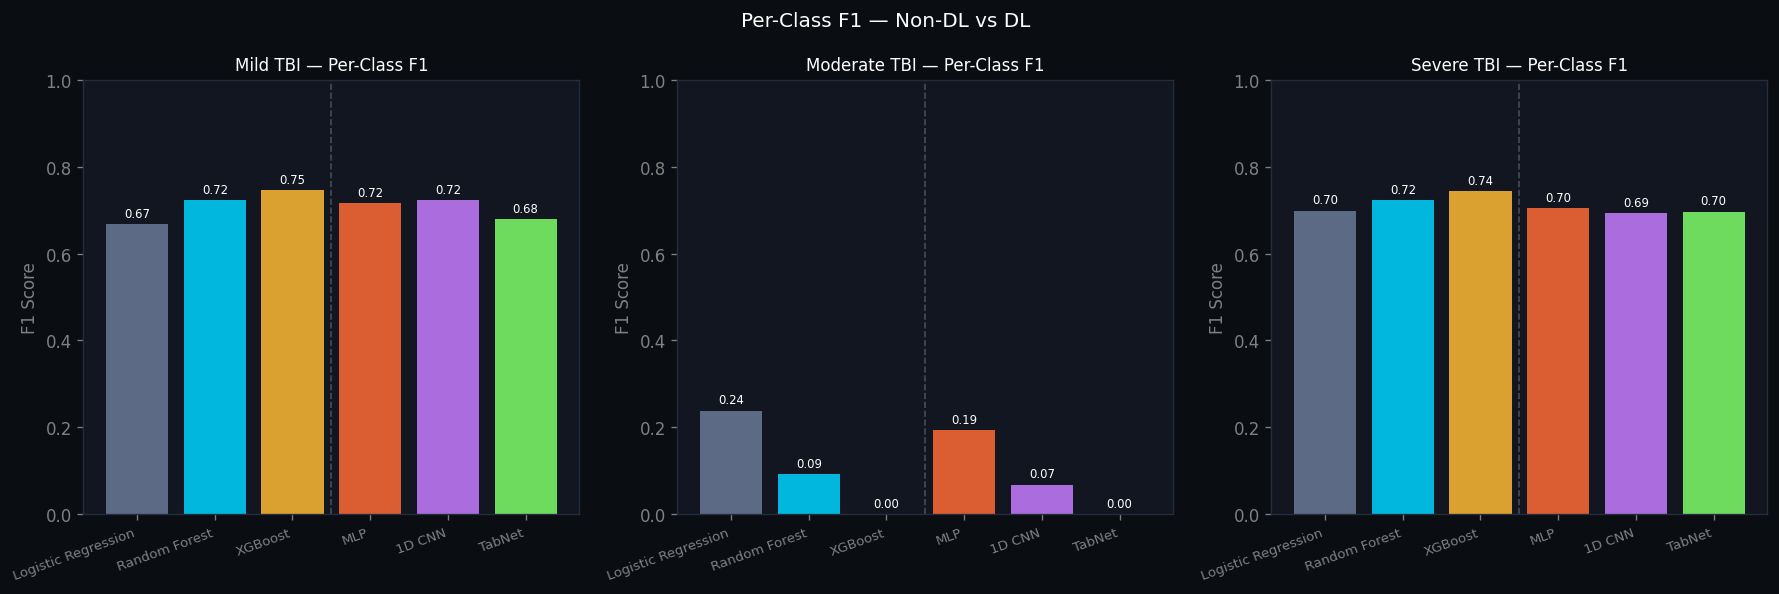


────────────────────────────────────────────────────────────
  DL Training Curves
────────────────────────────────────────────────────────────


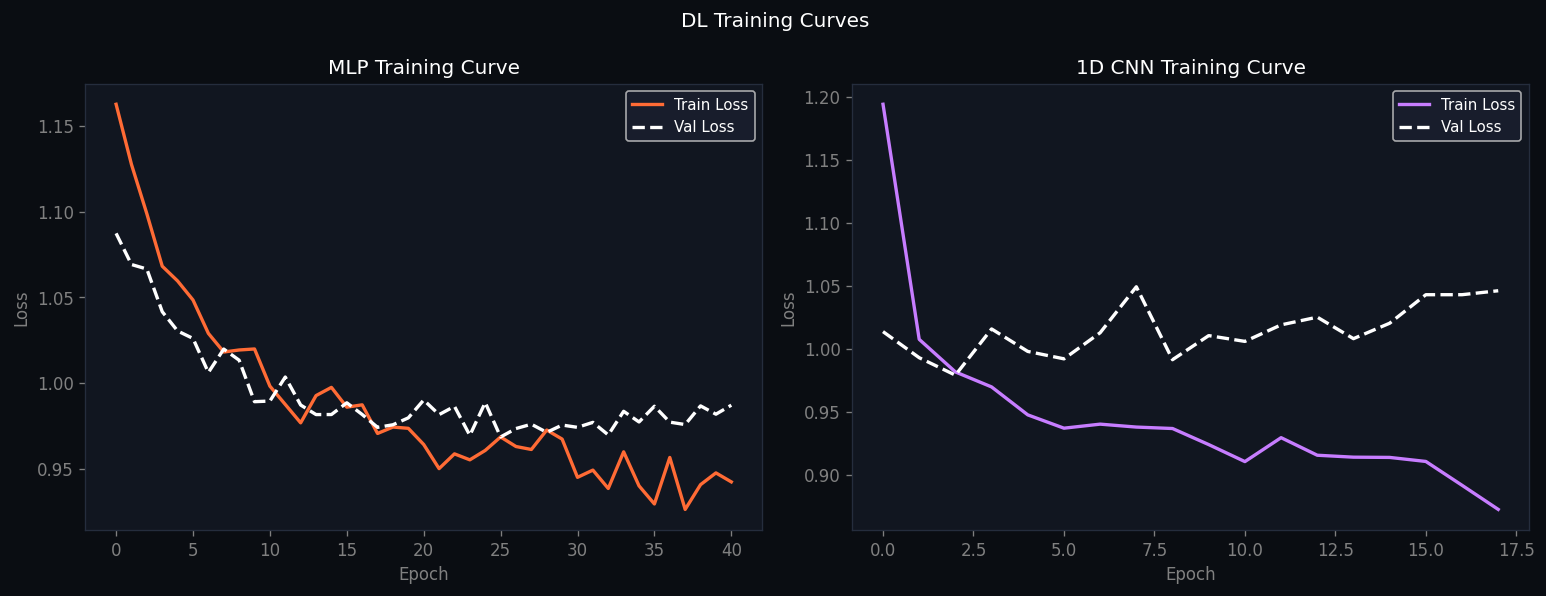


────────────────────────────────────────────────────────────
  SHAP Importance
────────────────────────────────────────────────────────────


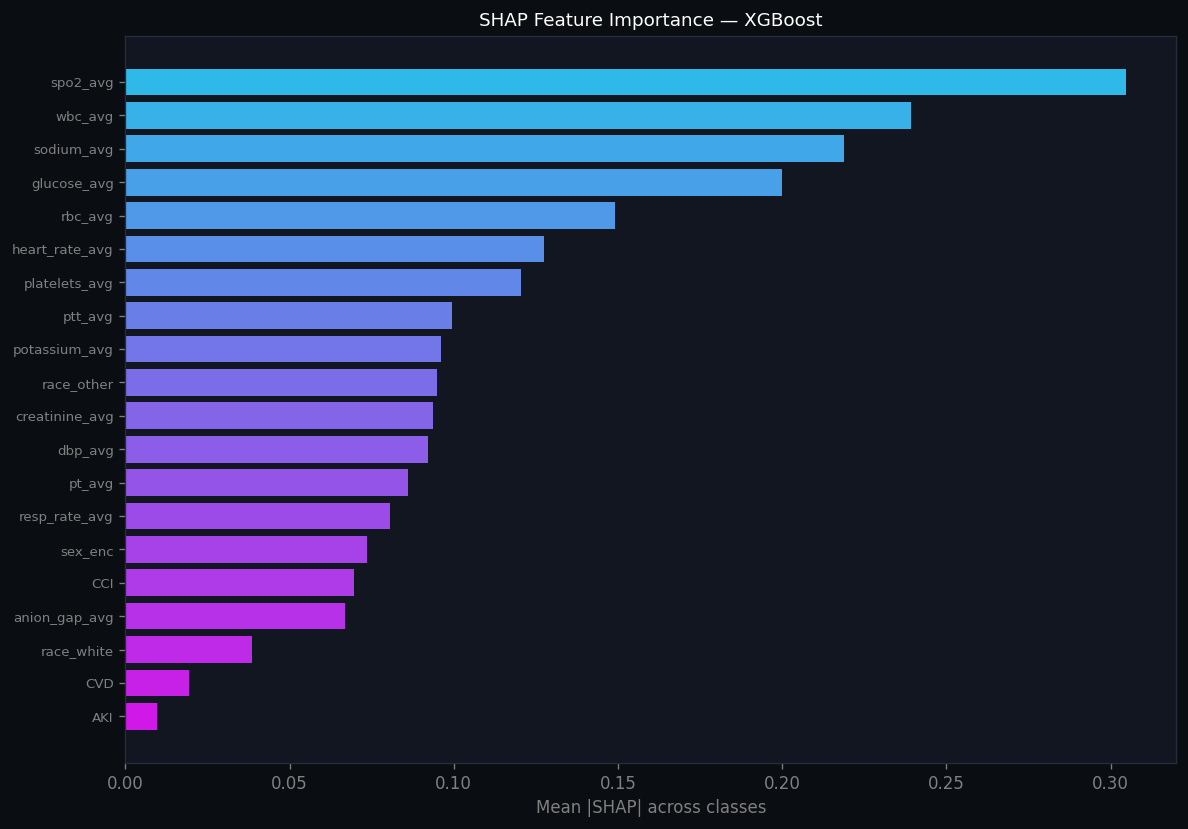


FINAL SUMMARY — TBI Severity Classification

Model                       AUC      Acc       F1  Type
───────────────────────────────────────────────────────
Logistic Regression      0.7903   0.6022   0.6229  Non-DL
Random Forest            0.8044   0.6583   0.6362  Non-DL
XGBoost                  0.8106   0.6911   0.6429  Non-DL
MLP                      0.7995   0.6349   0.6388  DL   
1D CNN                   0.7847   0.6490   0.6191  DL   
TabNet                   0.7404   0.6412   0.5940  DL   

✓ Best overall: XGBoost (AUC=0.8106)

Per-class classification report (XGBoost):

              precision    recall  f1-score   support

        Mild       0.70      0.80      0.75       260
    Moderate       0.00      0.00      0.00        88
      Severe       0.70      0.80      0.74       293

    accuracy                           0.69       641
   macro avg       0.46      0.53      0.50       641
weighted avg       0.60      0.69      0.64       641


How to read the plots:
  model_c

TypeError: 'numpy.float64' object is not callable

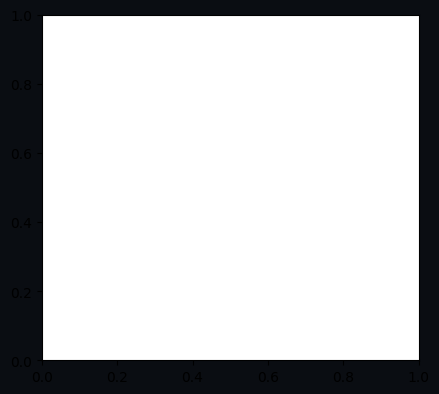

In [1]:
# ============================================================
# TBI SEVERITY CLASSIFICATION — COMBINED PIPELINE
# Non-DL: Logistic Regression, Random Forest, XGBoost
# DL:     MLP, 1D CNN, TabNet
# Predicts: Mild / Moderate / Severe TBI
# Google Colab Ready
# ============================================================


# ────────────────────────────────────────────────────────────
# CELL 1 — Install dependencies
# ────────────────────────────────────────────────────────────

!pip install pytorch-tabnet xgboost shap optuna --quiet



# ────────────────────────────────────────────────────────────
# CELL 2 — Upload data
# ────────────────────────────────────────────────────────────
"""
from google.colab import files
uploaded = files.upload()   # select TBi_3205_Allfeature.csv
"""


# ────────────────────────────────────────────────────────────
# CELL 3 — Imports
# ────────────────────────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from pytorch_tabnet.tab_model import TabNetClassifier

import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.model_selection import (StratifiedKFold, cross_validate,
                                      train_test_split, cross_val_score)
from sklearn.metrics import (roc_auc_score, roc_curve, auc,
                              f1_score, accuracy_score,
                              classification_report, confusion_matrix)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.pipeline import Pipeline

import shap
from IPython.display import display, Image
import os

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✓ Device: {DEVICE}")
print("✓ All imports successful")


# ────────────────────────────────────────────────────────────
# CELL 4 — Configuration
# ────────────────────────────────────────────────────────────

DATA_FILE   = "TBi_3205_Allfeature.csv"
RANDOM_SEED = 42
N_FOLDS     = 5
EPOCHS      = 100
PATIENCE    = 15
BATCH_SIZE  = 64
CLASS_NAMES = ["Mild", "Moderate", "Severe"]

# GCS columns — excluded to avoid data leakage
# (severity is derived FROM gcs_total_min)
GCS_COLS = ["gcs_total_avg"]

COMORBIDITY_COLS = ["CHF", "liver", "chronic_lung_disease", "CVD",
                    "malignant", "AKI", "CCI"]
VITAL_COLS = [
    "heart_rate_avg",
    "resp_rate_avg",
    "dbp_avg",
    "spo2_avg",
]
LAB_COLS = [
        "wbc_avg",
    "creatinine_avg",
     "glucose_avg",
    "platelets_avg",
   "anion_gap_avg",
     "sodium_avg",
     "potassium_avg",
        "rbc_avg",
]
COAG_COLS     = ["pt_avg",
                  "ptt_avg"]
##SEVERITY_COLS = ["apsiii", "sofa"]  ## # oasis and sapsii removed

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
print("✓ Configuration set")


# ────────────────────────────────────────────────────────────
# CELL 5 — Load & prepare data
# ────────────────────────────────────────────────────────────
# Steps:
#   1. Load CSV
#   2. Derive TBI severity from GCS (Mild=0, Moderate=1, Severe=2)
#   3. Encode sex and race
#   4. Add missingness flags for PT/PTT
#   5. KNN impute missing values
#   6. Scale features (needed for DL models)
#   7. Train/test split

print("=" * 60)
print("STEP 1 — Loading & Preparing Data")
print("=" * 60)

df = pd.read_csv(DATA_FILE)
print(f"Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")

# Derive severity from GCS minimum score
def get_severity(gcs):
    if pd.isna(gcs): return np.nan
    elif gcs >= 13:  return 0   # Mild
    elif gcs >= 9:   return 1   # Moderate
    else:            return 2   # Severe

df["tbi_severity"] = df["gcs_total_min"].apply(get_severity)
df = df[df["tbi_severity"].notna()].copy()
df["tbi_severity"] = df["tbi_severity"].astype(int)

print("\nClass distribution:")
for i, name in enumerate(CLASS_NAMES):
    n = (df["tbi_severity"] == i).sum()
    print(f"  {name:>10}: {n:,} ({n/len(df)*100:.1f}%)")

# Encode sex
df["sex_enc"] = (df["sex"] == "M").astype(int)

# Encode race into broad groups
def encode_race(r):
    if pd.isna(r): return "unknown"
    r = str(r).upper()
    if "WHITE"    in r: return "white"
    if "BLACK"    in r: return "black"
    if "HISPANIC" in r: return "hispanic"
    if "ASIAN"    in r: return "asian"
    return "other"

df["race_grp"] = df["race"].apply(encode_race)
race_dummies   = pd.get_dummies(df["race_grp"], prefix="race", drop_first=True)
df             = pd.concat([df, race_dummies], axis=1)
RACE_COLS      = race_dummies.columns.tolist()

# Missingness flags — whether PT/PTT was tested is itself a signal
COAG_FLAGS = []
for col in COAG_COLS:
    flag = f"{col}_missing"
    df[flag] = df[col].isna().astype(int)
    COAG_FLAGS.append(flag)

# Build feature list — exclude all GCS columns
ALL_FEATURES = (COMORBIDITY_COLS + VITAL_COLS + LAB_COLS +
                COAG_COLS + COAG_FLAGS +
                ["sex_enc", "MST"] + RACE_COLS)
ALL_FEATURES = [c for c in ALL_FEATURES
                if c in df.columns and c not in GCS_COLS]

X_raw = df[ALL_FEATURES].copy()
y     = df["tbi_severity"].values

# Drop features with >50% missing
keep  = X_raw.columns[X_raw.isnull().mean() < 0.5]
X_raw = X_raw[keep].copy()

# KNN imputation
print("\nImputing (KNN)...", end=" ")
imputer  = KNNImputer(n_neighbors=5)
X_imp    = imputer.fit_transform(X_raw)
X_imp    = pd.DataFrame(X_imp, columns=X_raw.columns)
print("done")

# Scale — critical for neural networks, harmless for tree models
scaler        = StandardScaler()
X_scaled      = scaler.fit_transform(X_imp).astype(np.float32)
feature_names = X_raw.columns.tolist()
N_FEATURES    = X_scaled.shape[1]

# Class weights — handles Moderate being minority class
class_weights        = compute_class_weight("balanced",
                                             classes=np.array([0, 1, 2]), y=y)
class_weights_tensor = torch.FloatTensor(class_weights).to(DEVICE)
print(f"✓ Class weights: {dict(zip(CLASS_NAMES, class_weights.round(2)))}")

# 80/20 stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2,
    random_state=RANDOM_SEED, stratify=y
)
print(f"✓ Train: {len(X_train):,}  Test: {len(X_test):,}")
print(f"✓ Features: {N_FEATURES}")


# ────────────────────────────────────────────────────────────
# CELL 6 — Non-DL Models (Logistic Regression, RF, XGBoost)
# ────────────────────────────────────────────────────────────
# Standard ML models trained with 5-fold stratified CV.
# Metrics: weighted AUC-ROC, accuracy, weighted F1.

print("\n" + "=" * 60)
print("STEP 2 — Non-DL Models (Cross-Validation)")
print("=" * 60)

cv_strat = StratifiedKFold(n_splits=N_FOLDS, shuffle=True,
                            random_state=RANDOM_SEED)
scoring  = {
    "AUC":      "roc_auc_ovo_weighted",
    "Accuracy": "accuracy",
    "F1":       "f1_weighted",
}

non_dl_models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf",    LogisticRegression(max_iter=1000,
                                       class_weight="balanced",
                                       multi_class="multinomial",
                                       random_state=RANDOM_SEED)),
    ]),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, class_weight="balanced",
        random_state=RANDOM_SEED, n_jobs=-1,
    ),
    "XGBoost": xgb.XGBClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=5,
        tree_method="hist", objective="multi:softprob",
        num_class=3, eval_metric="mlogloss",
        random_state=RANDOM_SEED, verbosity=0,
    ),
}

non_dl_cv_results = {}
print(f"\nRunning {N_FOLDS}-fold CV...\n")

for name, model in non_dl_models.items():
    print(f"  {name}...", end=" ", flush=True)
    res = cross_validate(model, X_scaled, y, cv=cv_strat,
                          scoring=scoring, n_jobs=-1)
    non_dl_cv_results[name] = res
    print(f"AUC={res['test_AUC'].mean():.3f}±{res['test_AUC'].std():.3f}  "
          f"F1={res['test_F1'].mean():.3f}")

# ────────────────────────────────────────────────────────────
# CELL 6b — Non-DL Hyperparameter Tuning (Optuna)
# ────────────────────────────────────────────────────────────
# Tunes Random Forest and XGBoost using Bayesian optimisation.
# Logistic Regression has only one meaningful param (C/alpha)
# so it is tuned via a simple grid.
# Objective: maximise weighted AUC-OVO on stratified CV.

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

print("\nTuning Non-DL models (Optuna, 50 trials each)...")

# ── Logistic Regression — grid over C ─────────────────────────
print("\n  [1/3] Logistic Regression (grid over C)...")
from sklearn.model_selection import cross_val_score

best_lr_C   = 0.01
best_lr_auc = 0.0
for C in [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]:
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("clf",    LogisticRegression(
            C=C, max_iter=1000, class_weight="balanced",
            multi_class="multinomial", random_state=RANDOM_SEED)),
    ])
    aucs = cross_val_score(
        pipe, X_scaled, y, cv=cv_strat,
        scoring="roc_auc_ovo_weighted", n_jobs=-1)
    if aucs.mean() > best_lr_auc:
        best_lr_auc = aucs.mean()
        best_lr_C   = C

print(f"    ✓ Best C={best_lr_C}  AUC={best_lr_auc:.4f}")

# ── Random Forest Tuning ──────────────────────────────────────
print("\n  [2/3] Random Forest (50 trials)...")

def rf_clf_objective(trial):
    params = {
        "n_estimators":      trial.suggest_int("n_estimators", 100, 600),
        "max_depth":         trial.suggest_int("max_depth", 3, 20),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf":  trial.suggest_int("min_samples_leaf",  1, 10),
        "max_features":      trial.suggest_categorical(
                                 "max_features", ["sqrt", "log2", 0.5]),
    }
    model = RandomForestClassifier(
        **params, class_weight="balanced",
        random_state=RANDOM_SEED, n_jobs=-1
    )
    aucs = cross_val_score(
        model, X_train, y_train, cv=cv_strat,
        scoring="roc_auc_ovo_weighted", n_jobs=-1)
    return aucs.mean()

rf_study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED)
)
rf_study.optimize(rf_clf_objective, n_trials=50, show_progress_bar=True)
best_rf_params = rf_study.best_params
print(f"    ✓ Best RF AUC: {rf_study.best_value:.4f}")
print(f"      Params: {best_rf_params}")

# ── XGBoost Tuning ────────────────────────────────────────────
print("\n  [3/3] XGBoost (50 trials)...")

def xgb_clf_objective(trial):
    params = {
        "n_estimators":   trial.suggest_int("n_estimators",   100, 600),
        "learning_rate":  trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "max_depth":      trial.suggest_int("max_depth",       3, 10),
        "subsample":      trial.suggest_float("subsample",     0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha":      trial.suggest_float("reg_alpha",     1e-4, 10.0, log=True),
        "reg_lambda":     trial.suggest_float("reg_lambda",    1e-4, 10.0, log=True),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
    }
    model = xgb.XGBClassifier(
        **params,
        tree_method="hist", objective="multi:softprob",
        num_class=3, eval_metric="mlogloss",
        random_state=RANDOM_SEED, verbosity=0,
    )
    aucs = cross_val_score(
        model, X_train, y_train, cv=cv_strat,
        scoring="roc_auc_ovo_weighted", n_jobs=-1)
    return aucs.mean()

xgb_study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED)
)
xgb_study.optimize(xgb_clf_objective, n_trials=50, show_progress_bar=True)
best_xgb_params = xgb_study.best_params
print(f"    ✓ Best XGB AUC: {xgb_study.best_value:.4f}")
print(f"      Params: {best_xgb_params}")

# ── Train final non-DL models with tuned params ───────────────
print("\nTraining final non-DL models with tuned hyperparameters...")

non_dl_final = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf",    LogisticRegression(
            C=best_lr_C, max_iter=1000, class_weight="balanced",
            multi_class="multinomial", random_state=RANDOM_SEED)),
    ]),
    "Random Forest": RandomForestClassifier(
        **best_rf_params, class_weight="balanced",
        random_state=RANDOM_SEED, n_jobs=-1
    ),
    "XGBoost": xgb.XGBClassifier(
        **best_xgb_params,
        tree_method="hist", objective="multi:softprob",
        num_class=3, eval_metric="mlogloss",
        random_state=RANDOM_SEED, verbosity=0,
    ),
}

for name, model in non_dl_final.items():
    model.fit(X_train, y_train)
    print(f"  ✓ {name}")

print("\nNon-DL tuning complete.")
print(f"  LR  best C:           {best_lr_C}")
print(f"  RF  best n_estimators: {best_rf_params['n_estimators']}, "
      f"max_depth: {best_rf_params['max_depth']}")
print(f"  XGB best lr:           {best_xgb_params['learning_rate']:.4f}, "
      f"max_depth: {best_xgb_params['max_depth']}, "
      f"n_estimators: {best_xgb_params['n_estimators']}")


# ────────────────────────────────────────────────────────────
# CELL 7 — DL Model Definitions
# ────────────────────────────────────────────────────────────

print("\n" + "=" * 60)
print("STEP 3 — DL Model Definitions")
print("=" * 60)

class MLPClassifier(nn.Module):
    """
    Multi-Layer Perceptron for 3-class classification.
    BatchNorm stabilises training, Dropout prevents overfitting.
    Output: 3 logits (one per class) — softmax applied by loss function.
    """
    def __init__(self, n_features, n_classes=3,
                 hidden=[256, 128, 64], dropout=0.3):
        super().__init__()
        layers, in_dim = [], n_features
        for h in hidden:
            layers += [nn.Linear(in_dim, h), nn.BatchNorm1d(h),
                       nn.ReLU(), nn.Dropout(dropout)]
            in_dim = h
        layers.append(nn.Linear(in_dim, n_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


class CNN1DClassifier(nn.Module):
    """
    1D Convolutional Network for 3-class classification.
    Treats patient features as a 1D signal.
    Conv layers learn local feature interactions.
    """
    def __init__(self, n_features, n_classes=3, dropout=0.3):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(1, 64,  kernel_size=3, padding=1),
            nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(dropout),
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128), nn.ReLU(),
            nn.AdaptiveAvgPool1d(16),
        )
        self.clf = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16, 128), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(128, n_classes),
        )

    def forward(self, x):
        return self.clf(self.conv(x.unsqueeze(1)))


print("✓ MLP Classifier defined")
print("✓ 1D CNN Classifier defined")
print("✓ TabNet Classifier will be initialised per fold")


# ────────────────────────────────────────────────────────────
# CELL 8 — DL Training utilities
# ────────────────────────────────────────────────────────────

def train_epoch_clf(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    for Xb, yb in loader:
        Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(Xb), yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


def eval_epoch_clf(model, loader, criterion):
    model.eval()
    total_loss, all_probs, all_labels = 0, [], []
    with torch.no_grad():
        for Xb, yb in loader:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            logits = model(Xb)
            total_loss  += criterion(logits, yb).item()
            all_probs   += torch.softmax(logits, dim=1).cpu().tolist()
            all_labels  += yb.cpu().tolist()
    return (total_loss / len(loader),
            np.array(all_probs), np.array(all_labels))


def train_model_clf(model, X_tr, y_tr, X_val, y_val,
                    epochs=EPOCHS, patience=PATIENCE, lr=1e-3):
    """Training loop with early stopping and class-weighted loss."""
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)

    # FIX: verbose removed — not supported in newer PyTorch
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=5, factor=0.5
    )

    tr_loader  = DataLoader(
        TensorDataset(torch.FloatTensor(X_tr),
                      torch.LongTensor(y_tr)),
        batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(
        TensorDataset(torch.FloatTensor(X_val),
                      torch.LongTensor(y_val)),
        batch_size=BATCH_SIZE)

    best_val_loss = np.inf
    best_state    = None
    patience_ctr  = 0
    history       = {"train_loss": [], "val_loss": []}

    for epoch in range(epochs):
        tr_loss            = train_epoch_clf(model, tr_loader, optimizer, criterion)
        val_loss, _, _     = eval_epoch_clf(model, val_loader, criterion)
        scheduler.step(val_loss)
        history["train_loss"].append(tr_loss)
        history["val_loss"].append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state    = {k: v.clone() for k, v in model.state_dict().items()}
            patience_ctr  = 0
        else:
            patience_ctr += 1
            if patience_ctr >= patience:
                break

    model.load_state_dict(best_state)
    return model, history


# ────────────────────────────────────────────────────────────
# CELL 9 — DL Cross-validation
# ────────────────────────────────────────────────────────────

print("\n" + "=" * 60)
print("STEP 4 — DL Models (Cross-Validation)")
print("=" * 60)

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True,
                       random_state=RANDOM_SEED)

def run_cv_clf(model_fn, model_name, X, y):
    """K-fold CV for DL classifiers. Returns AUC and F1 per fold."""
    fold_aucs, fold_f1s, histories = [], [], []
    print(f"\n  {model_name}:")

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y)):
        X_tr, X_val = X[tr_idx], X[val_idx]
        y_tr, y_val = y[tr_idx], y[val_idx]

        model          = model_fn().to(DEVICE)
        model, history = train_model_clf(model, X_tr, y_tr, X_val, y_val)
        histories.append(history)

        criterion  = nn.CrossEntropyLoss(weight=class_weights_tensor)
        val_loader = DataLoader(
            TensorDataset(torch.FloatTensor(X_val),
                          torch.LongTensor(y_val)),
            batch_size=BATCH_SIZE)

        _, probs, labels = eval_epoch_clf(model, val_loader, criterion)
        preds  = np.argmax(probs, axis=1)
        labels = labels.astype(int)

        auc = roc_auc_score(labels, probs, multi_class="ovr", average="weighted")
        f1  = f1_score(labels, preds, average="weighted")
        fold_aucs.append(auc)
        fold_f1s.append(f1)
        print(f"    Fold {fold+1}: AUC={auc:.3f}  F1={f1:.3f}")

    print(f"  → Mean: AUC={np.mean(fold_aucs):.3f}±{np.std(fold_aucs):.3f}  "
          f"F1={np.mean(fold_f1s):.3f}±{np.std(fold_f1s):.3f}")
    return {"auc": fold_aucs, "f1": fold_f1s, "histories": histories}


mlp_cv  = run_cv_clf(lambda: MLPClassifier(N_FEATURES), "MLP",
                      X_train, y_train)
cnn_cv  = run_cv_clf(lambda: CNN1DClassifier(N_FEATURES), "1D CNN",
                      X_train, y_train)

# TabNet CV
print("\n  TabNet:")
tab_aucs, tab_f1s = [], []
for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
    X_tr, X_val = X_train[tr_idx], X_train[val_idx]
    y_tr, y_val = y_train[tr_idx], y_train[val_idx]

    tabnet = TabNetClassifier(
        n_d=32, n_a=32, n_steps=5, gamma=1.3,
        seed=RANDOM_SEED, device_name=str(DEVICE), verbose=0
    )
    tabnet.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        eval_metric=["accuracy"],
        max_epochs=100, patience=15, batch_size=BATCH_SIZE,
    )
    probs = tabnet.predict_proba(X_val)
    preds = np.argmax(probs, axis=1)
    auc   = roc_auc_score(y_val, probs, multi_class="ovr", average="weighted")
    f1    = f1_score(y_val, preds, average="weighted")
    tab_aucs.append(auc)
    tab_f1s.append(f1)
    print(f"    Fold {fold+1}: AUC={auc:.3f}  F1={f1:.3f}")

print(f"  → Mean: AUC={np.mean(tab_aucs):.3f}±{np.std(tab_aucs):.3f}  "
      f"F1={np.mean(tab_f1s):.3f}±{np.std(tab_f1s):.3f}")
tabnet_cv = {"auc": tab_aucs, "f1": tab_f1s}


# ────────────────────────────────────────────────────────────
# CELL 10 — Hyperparameter Tuning (Optuna — All DL Models)
# ────────────────────────────────────────────────────────────
# Tunes MLP, 1D CNN, and TabNet using Bayesian optimisation.
# Each model runs 50 trials. The best hyperparameters from
# each study are then used to train the final models.
# Objective: maximise weighted F1 on a validation fold.

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

print("\n" + "=" * 60)
print("STEP 5 — Hyperparameter Tuning (Optuna, 50 trials each)")
print("=" * 60)

# Use a single internal val split for tuning speed (20% of train)
X_tune_tr, X_tune_val, y_tune_tr, y_tune_val = train_test_split(
    X_train, y_train, test_size=0.2,
    random_state=RANDOM_SEED, stratify=y_train
)

# ── MLP Tuning ────────────────────────────────────────────────
print("\n[1/3] Tuning MLP...")

def mlp_clf_objective(trial):
    h1      = trial.suggest_categorical("h1",      [128, 256, 512])
    h2      = trial.suggest_categorical("h2",      [64, 128, 256])
    h3      = trial.suggest_categorical("h3",      [32, 64, 128])
    dropout = trial.suggest_float("dropout",       0.1, 0.5)
    lr      = trial.suggest_float("lr",            1e-4, 1e-2, log=True)

    model = MLPClassifier(N_FEATURES,
                          hidden=[h1, h2, h3],
                          dropout=dropout).to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=5, factor=0.5)

    tr_loader  = DataLoader(
        TensorDataset(torch.FloatTensor(X_tune_tr),
                      torch.LongTensor(y_tune_tr)),
        batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(
        TensorDataset(torch.FloatTensor(X_tune_val),
                      torch.LongTensor(y_tune_val)),
        batch_size=BATCH_SIZE)

    best_val_loss = np.inf
    patience_ctr  = 0
    for epoch in range(60):   # shorter max for tuning speed
        train_epoch_clf(model, tr_loader, optimizer, criterion)
        val_loss, _, _ = eval_epoch_clf(model, val_loader, criterion)
        scheduler.step(val_loss)
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_ctr  = 0
        else:
            patience_ctr += 1
            if patience_ctr >= 10:
                break

    _, probs, labels = eval_epoch_clf(model, val_loader, criterion)
    preds = np.argmax(probs, axis=1)
    return f1_score(labels.astype(int), preds, average="weighted")

mlp_study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED)
)
mlp_study.optimize(mlp_clf_objective, n_trials=50, show_progress_bar=True)
best_mlp_params = mlp_study.best_params
print(f"  ✓ Best MLP F1: {mlp_study.best_value:.4f}")
print(f"    Params: {best_mlp_params}")

# ── CNN Tuning ────────────────────────────────────────────────
print("\n[2/3] Tuning 1D CNN...")

def cnn_clf_objective(trial):
    dropout  = trial.suggest_float("dropout", 0.1, 0.5)
    lr       = trial.suggest_float("lr",      1e-4, 1e-2, log=True)
    filters1 = trial.suggest_categorical("filters1", [32, 64, 128])
    filters2 = trial.suggest_categorical("filters2", [64, 128, 256])
    dense    = trial.suggest_categorical("dense",    [64, 128, 256])

    # Build custom CNN with tunable filters
    class TunedCNN(nn.Module):
        def __init__(self):
            super().__init__()
            self.conv = nn.Sequential(
                nn.Conv1d(1, filters1, kernel_size=3, padding=1),
                nn.BatchNorm1d(filters1), nn.ReLU(), nn.Dropout(dropout),
                nn.Conv1d(filters1, filters2, kernel_size=3, padding=1),
                nn.BatchNorm1d(filters2), nn.ReLU(),
                nn.AdaptiveAvgPool1d(16),
            )
            self.clf = nn.Sequential(
                nn.Flatten(),
                nn.Linear(filters2 * 16, dense), nn.ReLU(),
                nn.Dropout(dropout),
                nn.Linear(dense, 3),
            )
        def forward(self, x):
            return self.clf(self.conv(x.unsqueeze(1)))

    model     = TunedCNN().to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=5, factor=0.5)

    tr_loader  = DataLoader(
        TensorDataset(torch.FloatTensor(X_tune_tr),
                      torch.LongTensor(y_tune_tr)),
        batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(
        TensorDataset(torch.FloatTensor(X_tune_val),
                      torch.LongTensor(y_tune_val)),
        batch_size=BATCH_SIZE)

    best_val_loss = np.inf
    patience_ctr  = 0
    for epoch in range(60):
        train_epoch_clf(model, tr_loader, optimizer, criterion)
        val_loss, _, _ = eval_epoch_clf(model, val_loader, criterion)
        scheduler.step(val_loss)
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_ctr  = 0
        else:
            patience_ctr += 1
            if patience_ctr >= 10:
                break

    _, probs, labels = eval_epoch_clf(model, val_loader, criterion)
    preds = np.argmax(probs, axis=1)
    return f1_score(labels.astype(int), preds, average="weighted")

cnn_study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED)
)
cnn_study.optimize(cnn_clf_objective, n_trials=50, show_progress_bar=True)
best_cnn_params = cnn_study.best_params
print(f"  ✓ Best CNN F1: {cnn_study.best_value:.4f}")
print(f"    Params: {best_cnn_params}")

# ── TabNet Tuning ─────────────────────────────────────────────
print("\n[3/3] Tuning TabNet...")

def tabnet_clf_objective(trial):
    n_d    = trial.suggest_categorical("n_d",    [16, 32, 64])
    n_a    = trial.suggest_categorical("n_a",    [16, 32, 64])
    n_steps = trial.suggest_int("n_steps",       3, 7)
    gamma  = trial.suggest_float("gamma",        1.0, 2.0)
    lr     = trial.suggest_float("lr",           1e-3, 1e-1, log=True)
    bs     = trial.suggest_categorical("batch_size", [32, 64, 128])

    tabnet = TabNetClassifier(
        n_d=n_d, n_a=n_a, n_steps=n_steps, gamma=gamma,
        optimizer_params=dict(lr=lr),
        seed=RANDOM_SEED, device_name=str(DEVICE), verbose=0
    )
    tabnet.fit(
        X_tune_tr, y_tune_tr,
        eval_set=[(X_tune_val, y_tune_val)],
        eval_metric=["accuracy"],
        max_epochs=60, patience=10, batch_size=bs,
    )
    preds = tabnet.predict(X_tune_val)
    return f1_score(y_tune_val, preds, average="weighted")

tabnet_study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED)
)
tabnet_study.optimize(tabnet_clf_objective, n_trials=50,
                       show_progress_bar=True)
best_tabnet_params = tabnet_study.best_params
print(f"  ✓ Best TabNet F1: {tabnet_study.best_value:.4f}")
print(f"    Params: {best_tabnet_params}")

# ── Tuning summary plot ───────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.patch.set_facecolor("#0a0d12")

for ax, study, name, color in [
    (axes[0], mlp_study,    "MLP",    "#ff6b35"),
    (axes[1], cnn_study,    "1D CNN", "#c77dff"),
    (axes[2], tabnet_study, "TabNet", "#7fff6b"),
]:
    vals       = [t.value for t in study.trials if t.value is not None]
    best_so_far = pd.Series(vals).cummax()
    ax.scatter(range(len(vals)), vals,
               c=color, s=15, alpha=0.5)
    ax.plot(best_so_far.values, color="white", lw=2,
            label=f"Best={max(vals):.4f}")
    ax.set_xlabel("Trial", color="gray")
    ax.set_ylabel("Weighted F1", color="gray")
    ax.set_title(f"{name} Tuning", color="white")
    ax.set_facecolor("#111620")
    ax.tick_params(colors="gray")
    ax.spines[:].set_color("#252d3d")
    ax.legend(facecolor="#1a2030", labelcolor="white", fontsize=8)

plt.suptitle("Optuna Tuning — DL Models (Classification)",
             color="white", fontsize=12)
plt.tight_layout()
plt.savefig("optuna_tuning_clf.png", dpi=120,
            bbox_inches="tight", facecolor="#0a0d12")
plt.close()
print("\n✓ Saved: optuna_tuning_clf.png")
display(Image(filename="optuna_tuning_clf.png"))

print("\nTuning Summary:")
print(f"  MLP    best F1: {mlp_study.best_value:.4f}  "
      f"→ hidden={[best_mlp_params['h1'], best_mlp_params['h2'], best_mlp_params['h3']]}, "
      f"dropout={best_mlp_params['dropout']:.3f}, lr={best_mlp_params['lr']:.5f}")
print(f"  CNN    best F1: {cnn_study.best_value:.4f}  "
      f"→ filters=({best_cnn_params['filters1']},{best_cnn_params['filters2']}), "
      f"dense={best_cnn_params['dense']}, dropout={best_cnn_params['dropout']:.3f}")
print(f"  TabNet best F1: {tabnet_study.best_value:.4f}  "
      f"→ n_d={best_tabnet_params['n_d']}, n_steps={best_tabnet_params['n_steps']}, "
      f"gamma={best_tabnet_params['gamma']:.3f}")


# ────────────────────────────────────────────────────────────
# CELL 11 — Final evaluation on test set (with tuned models)
# ────────────────────────────────────────────────────────────

print("\n" + "=" * 60)
print("STEP 6 — Final Test Set Evaluation (Tuned Models)")
print("=" * 60)

# ── Tuned MLP ─────────────────────────────────────────────────
print("\nTraining tuned MLP...", end=" ")
mlp_final = MLPClassifier(
    N_FEATURES,
    hidden=[best_mlp_params["h1"],
            best_mlp_params["h2"],
            best_mlp_params["h3"]],
    dropout=best_mlp_params["dropout"]
).to(DEVICE)
mlp_final, mlp_history = train_model_clf(
    mlp_final, X_train, y_train, X_test, y_test,
    lr=best_mlp_params["lr"]
)
print("done")

# ── Tuned CNN ─────────────────────────────────────────────────
print("Training tuned CNN...", end=" ")

class TunedCNNFinal(nn.Module):
    def __init__(self):
        super().__init__()
        f1 = best_cnn_params["filters1"]
        f2 = best_cnn_params["filters2"]
        d  = best_cnn_params["dense"]
        dr = best_cnn_params["dropout"]
        self.conv = nn.Sequential(
            nn.Conv1d(1, f1, kernel_size=3, padding=1),
            nn.BatchNorm1d(f1), nn.ReLU(), nn.Dropout(dr),
            nn.Conv1d(f1, f2, kernel_size=3, padding=1),
            nn.BatchNorm1d(f2), nn.ReLU(),
            nn.AdaptiveAvgPool1d(16),
        )
        self.clf = nn.Sequential(
            nn.Flatten(),
            nn.Linear(f2 * 16, d), nn.ReLU(),
            nn.Dropout(dr),
            nn.Linear(d, 3),
        )
    def forward(self, x):
        return self.clf(self.conv(x.unsqueeze(1)))

cnn_final = TunedCNNFinal().to(DEVICE)
cnn_final, cnn_history = train_model_clf(
    cnn_final, X_train, y_train, X_test, y_test,
    lr=best_cnn_params["lr"]
)
print("done")

# ── Tuned TabNet ──────────────────────────────────────────────
print("Training tuned TabNet...", end=" ")
tabnet_final = TabNetClassifier(
    n_d=best_tabnet_params["n_d"],
    n_a=best_tabnet_params["n_a"],
    n_steps=best_tabnet_params["n_steps"],
    gamma=best_tabnet_params["gamma"],
    optimizer_params=dict(lr=best_tabnet_params["lr"]),
    seed=RANDOM_SEED, device_name=str(DEVICE), verbose=0
)
tabnet_final.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    eval_metric=["accuracy"],
    max_epochs=100, patience=15,
    batch_size=best_tabnet_params["batch_size"],
)
print("done")


def evaluate_dl(model, X, y_true):
    """Evaluate a PyTorch DL model on test set."""
    model.eval()
    loader = DataLoader(
        TensorDataset(torch.FloatTensor(X), torch.LongTensor(y_true)),
        batch_size=BATCH_SIZE)
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
    _, probs, _ = eval_epoch_clf(model, loader, criterion)
    preds = np.argmax(probs, axis=1)
    return {
        "auc":   roc_auc_score(y_true, probs, multi_class="ovr",
                                average="weighted"),
        "acc":   accuracy_score(y_true, preds),
        "f1":    f1_score(y_true, preds, average="weighted"),
        "preds": preds,
        "probs": probs,
    }


def evaluate_sklearn(model, X, y_true):
    """Evaluate a sklearn model on test set."""
    probs = model.predict_proba(X)
    preds = model.predict(X)
    return {
        "auc":   roc_auc_score(y_true, probs, multi_class="ovr",
                                average="weighted"),
        "acc":   accuracy_score(y_true, preds),
        "f1":    f1_score(y_true, preds, average="weighted"),
        "preds": preds,
        "probs": probs,
    }


# Collect all results
all_results = {}

for name, model in non_dl_final.items():
    all_results[name] = evaluate_sklearn(model, X_test, y_test)

all_results["MLP"]    = evaluate_dl(mlp_final,  X_test, y_test)
all_results["1D CNN"] = evaluate_dl(cnn_final,  X_test, y_test)
tab_probs             = tabnet_final.predict_proba(X_test)
tab_preds             = np.argmax(tab_probs, axis=1)
all_results["TabNet"] = {
    "auc":   roc_auc_score(y_test, tab_probs,
                            multi_class="ovr", average="weighted"),
    "acc":   accuracy_score(y_test, tab_preds),
    "f1":    f1_score(y_test, tab_preds, average="weighted"),
    "preds": tab_preds,
    "probs": tab_probs,
}

# Print summary table
print(f"\n{'Model':<22} {'AUC-ROC':>10} {'Accuracy':>10} {'F1':>10}  Type")
print("─" * 60)
for name, res in all_results.items():
    mtype = "Non-DL" if name in non_dl_models else "DL"
    print(f"{name:<22} {res['auc']:>10.4f} {res['acc']:>10.4f} "
          f"{res['f1']:>10.4f}  {mtype}")

best_model = max(all_results, key=lambda m: all_results[m]["auc"])
print(f"\n✓ Best model: {best_model} "
      f"(AUC={all_results[best_model]['auc']:.4f})")


# ────────────────────────────────────────────────────────────
# CELL 11 — Plots
# ────────────────────────────────────────────────────────────

print("\n" + "=" * 60)
print("STEP 7 — Generating Plots")
print("=" * 60)

MODEL_COLORS = {
    "Logistic Regression": "#6b7a99",
    "Random Forest":       "#00d4ff",
    "XGBoost":             "#ffbb33",
    "MLP":                 "#ff6b35",
    "1D CNN":              "#c77dff",
    "TabNet":              "#7fff6b",
}

# ── Plot 1: AUC comparison bar chart ─────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor("#0a0d12")

for ax, metric, label in zip(axes,
    ["auc", "acc", "f1"],
    ["AUC-ROC", "Accuracy", "F1 (weighted)"]):

    names  = list(all_results.keys())
    values = [all_results[n][metric] for n in names]
    colors = [MODEL_COLORS[n] for n in names]

    bars = ax.bar(range(len(names)), values, color=colors, alpha=0.85)
    ax.set_xticks(range(len(names)))
    ax.set_xticklabels(names, rotation=20, ha="right", fontsize=8)
    ax.set_ylabel(label, color="gray")
    ax.set_title(label, color="white")
    ax.set_facecolor("#111620")
    ax.tick_params(colors="gray")
    ax.spines[:].set_color("#252d3d")
    ax.set_ylim(0.5, 1.0)

    # Add value labels on bars
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.005,
                f"{val:.3f}", ha="center", va="bottom",
                fontsize=7, color="white")

    # Divider between Non-DL and DL
    ax.axvline(2.5, color="gray", lw=1, linestyle="--", alpha=0.5)
    ax.text(0.8, 0.52, "Non-DL", color="gray", fontsize=7, alpha=0.7)
    ax.text(3.2, 0.52, "DL",     color="gray", fontsize=7, alpha=0.7)

plt.suptitle("Non-DL vs DL — TBI Severity Classification",
             color="white", fontsize=13)
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=120,
            bbox_inches="tight", facecolor="#0a0d12")
plt.close()
print("✓ Saved: model_comparison.png")

# ── Plot 2: Confusion matrices — all 6 models ────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.patch.set_facecolor("#0a0d12")
axes = axes.flatten()

for ax, (name, res) in zip(axes, all_results.items()):
    cm     = confusion_matrix(y_test, res["preds"])
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    im     = ax.imshow(cm_pct, cmap="Blues", vmin=0, vmax=100)
    ax.set_xticks(range(3))
    ax.set_yticks(range(3))
    ax.set_xticklabels(CLASS_NAMES, fontsize=8, color="gray")
    ax.set_yticklabels(CLASS_NAMES, fontsize=8, color="gray")
    ax.set_xlabel("Predicted", color="gray", fontsize=8)
    ax.set_ylabel("Actual",    color="gray", fontsize=8)
    mtype = "Non-DL" if name in non_dl_models else "DL"
    ax.set_title(f"{name} ({mtype})\nAUC={res['auc']:.3f}",
                 color=MODEL_COLORS[name], fontsize=9)
    ax.set_facecolor("#111620")
    for i in range(3):
        for j in range(3):
            ax.text(j, i, f"{cm_pct[i,j]:.0f}%\n(n={cm[i,j]})",
                    ha="center", va="center", fontsize=7,
                    color="white" if cm_pct[i,j] > 50 else "gray")

plt.suptitle("Confusion Matrices — All Models (%)",
             color="white", fontsize=13)
plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=120,
            bbox_inches="tight", facecolor="#0a0d12")
plt.close()
print("✓ Saved: confusion_matrices.png")

# ── Plot 3: Per-class F1 comparison ──────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.patch.set_facecolor("#0a0d12")

for ax, class_idx, class_name in zip(axes, [0, 1, 2], CLASS_NAMES):
    names   = list(all_results.keys())
    f1s     = []
    for name, res in all_results.items():
        report = classification_report(
            y_test, res["preds"],
            target_names=CLASS_NAMES,
            output_dict=True
        )
        f1s.append(report[class_name]["f1-score"])

    colors = [MODEL_COLORS[n] for n in names]
    bars   = ax.bar(range(len(names)), f1s, color=colors, alpha=0.85)
    ax.set_xticks(range(len(names)))
    ax.set_xticklabels(names, rotation=20, ha="right", fontsize=8)
    ax.set_ylabel("F1 Score", color="gray")
    ax.set_title(f"{class_name} TBI — Per-Class F1",
                 color="white", fontsize=10)
    ax.set_facecolor("#111620")
    ax.tick_params(colors="gray")
    ax.spines[:].set_color("#252d3d")
    ax.set_ylim(0, 1.0)
    ax.axvline(2.5, color="gray", lw=1, linestyle="--", alpha=0.5)
    for bar, val in zip(bars, f1s):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.01,
                f"{val:.2f}", ha="center", va="bottom",
                fontsize=7, color="white")

plt.suptitle("Per-Class F1 — Non-DL vs DL",
             color="white", fontsize=12)
plt.tight_layout()
plt.savefig("perclass_f1.png", dpi=120,
            bbox_inches="tight", facecolor="#0a0d12")
plt.close()
print("✓ Saved: perclass_f1.png")

# ── Plot 4: DL training loss curves ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor("#0a0d12")

for ax, history, title, color in [
    (axes[0], mlp_history, "MLP Training Curve",    "#ff6b35"),
    (axes[1], cnn_history, "1D CNN Training Curve",  "#c77dff"),
]:
    ax.plot(history["train_loss"], color=color,   lw=2, label="Train Loss")
    ax.plot(history["val_loss"],   color="white", lw=2,
            linestyle="--", label="Val Loss")
    ax.set_xlabel("Epoch", color="gray")
    ax.set_ylabel("Loss",  color="gray")
    ax.set_title(title, color="white")
    ax.set_facecolor("#111620")
    ax.tick_params(colors="gray")
    ax.spines[:].set_color("#252d3d")
    ax.legend(facecolor="#1a2030", labelcolor="white", fontsize=9)

plt.suptitle("DL Training Curves", color="white", fontsize=12)
plt.tight_layout()
plt.savefig("dl_training_curves.png", dpi=120,
            bbox_inches="tight", facecolor="#0a0d12")
plt.close()
print("✓ Saved: dl_training_curves.png")

# ── Plot 5: CV AUC comparison (boxplot) ──────────────────────
fig, ax = plt.subplots(figsize=(11, 5))
fig.patch.set_facecolor("#0a0d12")
ax.set_facecolor("#111620")

cv_aucs = {
    "Logistic Regression": non_dl_cv_results["Logistic Regression"]["test_AUC"].tolist(),
    "Random Forest":       non_dl_cv_results["Random Forest"]["test_AUC"].tolist(),
    "XGBoost":             non_dl_cv_results["XGBoost"]["test_AUC"].tolist(),
    "MLP":                 mlp_cv["auc"],
    "1D CNN":              cnn_cv["auc"],
    "TabNet":              tabnet_cv["auc"],
}

names  = list(cv_aucs.keys())
colors = [MODEL_COLORS[n] for n in names]

for i, (name, aucs) in enumerate(cv_aucs.items()):
    bp = ax.boxplot(aucs, positions=[i], widths=0.5,
                    patch_artist=True,
                    boxprops=dict(facecolor=MODEL_COLORS[name], alpha=0.7),
                    medianprops=dict(color="white", linewidth=2),
                    whiskerprops=dict(color="gray"),
                    capprops=dict(color="gray"),
                    flierprops=dict(marker="o", color="gray", markersize=4))

ax.axvline(2.5, color="gray", lw=1, linestyle="--", alpha=0.6)
ax.text(0.8, ax.get_ylim()[0] + 0.001, "Non-DL",
        color="gray", fontsize=8, alpha=0.7)
ax.text(3.2, ax.get_ylim()[0] + 0.001, "DL",
        color="gray", fontsize=8, alpha=0.7)
ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, rotation=15, ha="right", fontsize=9)
ax.set_ylabel("AUC-ROC (5-fold CV)", color="gray")
ax.set_title("Cross-Validation AUC — Non-DL vs DL",
             color="white", fontsize=11)
ax.tick_params(colors="gray")
ax.spines[:].set_color("#252d3d")
plt.tight_layout()
plt.savefig("cv_auc_comparison.png", dpi=120,
            bbox_inches="tight", facecolor="#0a0d12")
plt.close()
print("✓ Saved: cv_auc_comparison.png")

# ── Plot 6: SHAP for best non-DL model ───────────────────────
print("\nComputing SHAP for best non-DL model...")
best_nondl = max(
    {k: v for k, v in all_results.items() if k in non_dl_models},
    key=lambda m: all_results[m]["auc"]
)
print(f"  Best non-DL: {best_nondl}")

shap_model = non_dl_final[best_nondl]
if hasattr(shap_model, "named_steps"):
    shap_model = shap_model.named_steps["clf"]
    X_shap     = scaler.transform(X_imp)[:500]
else:
    X_shap = X_scaled[:500]

explainer       = shap.TreeExplainer(shap_model)
shap_values_raw = explainer.shap_values(X_shap)

# Handle old vs new SHAP format
if isinstance(shap_values_raw, list):
    shap_values = shap_values_raw
elif shap_values_raw.ndim == 3:
    shap_values = [shap_values_raw[:, :, i]
                   for i in range(shap_values_raw.shape[2])]
else:
    shap_values = [shap_values_raw]

mean_abs = np.mean([np.abs(shap_values[i]).mean(axis=0)
                    for i in range(len(shap_values))], axis=0)
global_imp = pd.Series(mean_abs,
                        index=feature_names[:len(mean_abs)]
                        ).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
fig.patch.set_facecolor("#0a0d12")
ax.set_facecolor("#111620")
colors_imp = plt.cm.cool(np.linspace(0.2, 0.9, 20))
ax.barh(range(20), global_imp.head(20).values[::-1],
        color=colors_imp[::-1], alpha=0.9)
ax.set_yticks(range(20))
ax.set_yticklabels(global_imp.head(20).index[::-1], fontsize=8)
ax.set_xlabel("Mean |SHAP| across classes", color="gray")
ax.set_title(f"SHAP Feature Importance — {best_nondl}",
             color="white", fontsize=11)
ax.tick_params(colors="gray")
ax.spines[:].set_color("#252d3d")
plt.tight_layout()
plt.savefig("shap_importance.png", dpi=120,
            bbox_inches="tight", facecolor="#0a0d12")
plt.close()
print("✓ Saved: shap_importance.png")

# ── Display all images ────────────────────────────────────────
ALL_IMAGES = [
    ("Model Comparison",       "model_comparison.png"),
    ("CV AUC Comparison",      "cv_auc_comparison.png"),
    ("Confusion Matrices",     "confusion_matrices.png"),
    ("Per-Class F1",           "perclass_f1.png"),
    ("DL Training Curves",     "dl_training_curves.png"),
    ("SHAP Importance",        "shap_importance.png"),
]

print("\n" + "=" * 60)
print("ALL IMAGES")
print("=" * 60)
for title, fname in ALL_IMAGES:
    if os.path.exists(fname):
        print(f"\n{'─'*60}\n  {title}\n{'─'*60}")
        display(Image(filename=fname))


# ────────────────────────────────────────────────────────────
# CELL 12 — Final summary
# ────────────────────────────────────────────────────────────

print("\n" + "=" * 60)
print("FINAL SUMMARY — TBI Severity Classification")
print("=" * 60)

print(f"\n{'Model':<22} {'AUC':>8} {'Acc':>8} {'F1':>8}  Type")
print("─" * 55)
for name, res in all_results.items():
    mtype = "Non-DL" if name in non_dl_models else "DL   "
    print(f"{name:<22} {res['auc']:>8.4f} {res['acc']:>8.4f} "
          f"{res['f1']:>8.4f}  {mtype}")

print(f"\n✓ Best overall: {best_model} "
      f"(AUC={all_results[best_model]['auc']:.4f})")

print(f"""
Per-class classification report ({best_model}):
""")
print(classification_report(
    y_test, all_results[best_model]["preds"],
    target_names=CLASS_NAMES
))

print("""
How to read the plots:
  model_comparison.png   → Overall AUC / Acc / F1 side by side
  cv_auc_comparison.png  → CV stability — tight box = consistent model
  confusion_matrices.png → Which classes each model confuses
  perclass_f1.png        → Which model handles Moderate best
  dl_training_curves.png → Val loss rising = overfitting
  shap_importance.png    → Which features drive predictions most

Key clinical note:
  Moderate TBI (GCS 9–12) is typically the hardest to classify.
  Check perclass_f1.png to see which model handles it best.
""")


# ────────────────────────────────────────────────────────────
# CELL 13 — ROC Curves (3 plots)
# ────────────────────────────────────────────────────────────
# Plot 1: 2×3 grid — each model gets its own panel with
#         per-class (Mild/Moderate/Severe) + macro ROC curves
# Plot 2: All 6 macro ROC curves on one axis (paper figure)
# Plot 3: Per-class panels — all 6 models overlaid per class

print("\n" + "=" * 60)
print("STEP 8 — ROC Curves")
print("=" * 60)

import matplotlib.gridspec as gridspec
from sklearn.preprocessing import label_binarize

CLASS_NAMES_ROC  = ["Mild", "Moderate", "Severe"]
CLASS_COLORS_ROC = ["#00d4ff", "#ffbb33", "#ff4444"]

def compute_roc_ovr(y_true, y_probs, n_classes=3):
    """One-vs-Rest ROC + macro average for multiclass."""
    y_bin = label_binarize(y_true, classes=list(range(n_classes)))
    fpr, tpr, roc_auc_dict = {}, {}, {}
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], y_probs[:, i])
        roc_auc_dict[i]    = auc(fpr[i], tpr[i])
    # Macro average
    all_fpr  = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(n_classes):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
    mean_tpr              /= n_classes
    fpr["macro"]           = all_fpr
    tpr["macro"]           = mean_tpr
    roc_auc_dict["macro"]  = auc(all_fpr, mean_tpr)
    return fpr, tpr, roc_auc_dict

# ── Plot 1: Individual 2×3 grid ──────────────────────────────
fig = plt.figure(figsize=(18, 11))
fig.patch.set_facecolor("#0a0d12")
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

for idx, (model_name, res) in enumerate(all_results.items()):
    ax  = fig.add_subplot(gs[idx // 3, idx % 3])
    fpr, tpr, roc_auc_d = compute_roc_ovr(y_test, res["probs"])

    for i, (cname, ccolor) in enumerate(
            zip(CLASS_NAMES_ROC, CLASS_COLORS_ROC)):
        ax.plot(fpr[i], tpr[i], color=ccolor, lw=1.8, alpha=0.85,
                label=f"{cname}  AUC={roc_auc_d[i]:.3f}")

    ax.plot(fpr["macro"], tpr["macro"], color="white", lw=2.5,
            linestyle="--",
            label=f"Macro  AUC={roc_auc_d['macro']:.3f}")
    ax.plot([0, 1], [0, 1], color="gray", lw=1,
            linestyle=":", alpha=0.5)

    mtype = "Non-DL" if model_name in non_dl_models else "DL"
    ax.set_title(f"{model_name}  ({mtype})",
                 color=MODEL_COLORS[model_name],
                 fontsize=10, fontweight="bold")
    ax.set_xlabel("False Positive Rate", color="gray", fontsize=8)
    ax.set_ylabel("True Positive Rate",  color="gray", fontsize=8)
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
    ax.set_facecolor("#111620")
    ax.tick_params(colors="gray", labelsize=7)
    ax.spines[:].set_color("#252d3d")
    ax.legend(facecolor="#1a2030", labelcolor="white",
               fontsize=7, loc="lower right")

fig.suptitle(
    "ROC Curves — TBI Severity Classification (One-vs-Rest)\n"
    "Mild (GCS 13–15)  |  Moderate (GCS 9–12)  |  Severe (GCS 3–8)",
    color="white", fontsize=13, y=1.01
)
plt.savefig("roc_individual_models.png", dpi=130,
            bbox_inches="tight", facecolor="#0a0d12")
plt.close()
print("✓ Saved: roc_individual_models.png")
display(Image(filename="roc_individual_models.png"))

# ── Plot 2: All models — macro AUC overlay ───────────────────
fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor("#0a0d12")
ax.set_facecolor("#111620")

for model_name, res in all_results.items():
    fpr, tpr, roc_auc_d = compute_roc_ovr(y_test, res["probs"])
    ls = "--" if model_name in non_dl_models else "-"
    ax.plot(fpr["macro"], tpr["macro"],
            color=MODEL_COLORS[model_name], lw=2.2, linestyle=ls,
            label=f"{model_name}  AUC={roc_auc_d['macro']:.3f}")

ax.plot([0, 1], [0, 1], color="gray", lw=1,
        linestyle=":", alpha=0.5, label="Random classifier")
ax.set_xlabel("False Positive Rate", color="gray", fontsize=11)
ax.set_ylabel("True Positive Rate",  color="gray", fontsize=11)
ax.set_title("Macro-Average ROC — All 6 Models\nNon-DL: dashed  |  DL: solid",
             color="white", fontsize=12)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
ax.tick_params(colors="gray")
ax.spines[:].set_color("#252d3d")
ax.legend(facecolor="#1a2030", labelcolor="white",
           fontsize=9, loc="lower right")
plt.tight_layout()
plt.savefig("roc_all_models_macro.png", dpi=130,
            bbox_inches="tight", facecolor="#0a0d12")
plt.close()
print("✓ Saved: roc_all_models_macro.png")
display(Image(filename="roc_all_models_macro.png"))

# ── Plot 3: Per-class — all models overlaid ──────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor("#0a0d12")

for ci, (cname, ctitle) in enumerate(zip(
        CLASS_NAMES_ROC,
        ["Mild (GCS 13–15)", "Moderate (GCS 9–12)", "Severe (GCS 3–8)"])):
    ax = axes[ci]
    ax.set_facecolor("#111620")
    for model_name, res in all_results.items():
        fpr, tpr, roc_auc_d = compute_roc_ovr(y_test, res["probs"])
        ls = "--" if model_name in non_dl_models else "-"
        ax.plot(fpr[ci], tpr[ci],
                color=MODEL_COLORS[model_name], lw=2, linestyle=ls,
                label=f"{model_name}  AUC={roc_auc_d[ci]:.3f}")
    ax.plot([0, 1], [0, 1], color="gray", lw=1,
            linestyle=":", alpha=0.5)
    ax.set_title(f"Class: {ctitle}", color="white",
                 fontsize=11, fontweight="bold")
    ax.set_xlabel("False Positive Rate", color="gray", fontsize=9)
    ax.set_ylabel("True Positive Rate",  color="gray", fontsize=9)
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
    ax.tick_params(colors="gray")
    ax.spines[:].set_color("#252d3d")
    ax.legend(facecolor="#1a2030", labelcolor="white",
               fontsize=7.5, loc="lower right")

fig.suptitle("Per-Class ROC — All 6 Models Overlaid\n"
             "Non-DL: dashed  |  DL: solid",
             color="white", fontsize=13)
plt.tight_layout()
plt.savefig("roc_per_class_all_models.png", dpi=130,
            bbox_inches="tight", facecolor="#0a0d12")
plt.close()
print("✓ Saved: roc_per_class_all_models.png")
display(Image(filename="roc_per_class_all_models.png"))

# ── AUC summary table ─────────────────────────────────────────
print(f"\n{'Model':<24} {'Mild':>8} {'Moderate':>10} "
      f"{'Severe':>8} {'Macro':>8}  Type")
print("─" * 68)
for model_name, res in all_results.items():
    fpr, tpr, roc_auc_d = compute_roc_ovr(y_test, res["probs"])
    mtype = "Non-DL" if model_name in non_dl_models else "DL    "
    print(f"{model_name:<24} {roc_auc_d[0]:>8.4f} {roc_auc_d[1]:>10.4f} "
          f"{roc_auc_d[2]:>8.4f} {roc_auc_d['macro']:>8.4f}  {mtype}")

print("""
ROC output files:
  roc_individual_models.png   — 2×3 grid: per-class + macro per model
  roc_all_models_macro.png    — all 6 macro curves overlaid (use in paper)
  roc_per_class_all_models.png — 3 panels: one per class, all models

Note: Moderate class typically has lowest AUC — boundary zone between
Mild and Severe makes it hardest to distinguish from both directions.
""")


STEP 8 — ROC Curves
✓ Saved: roc_individual_models.png


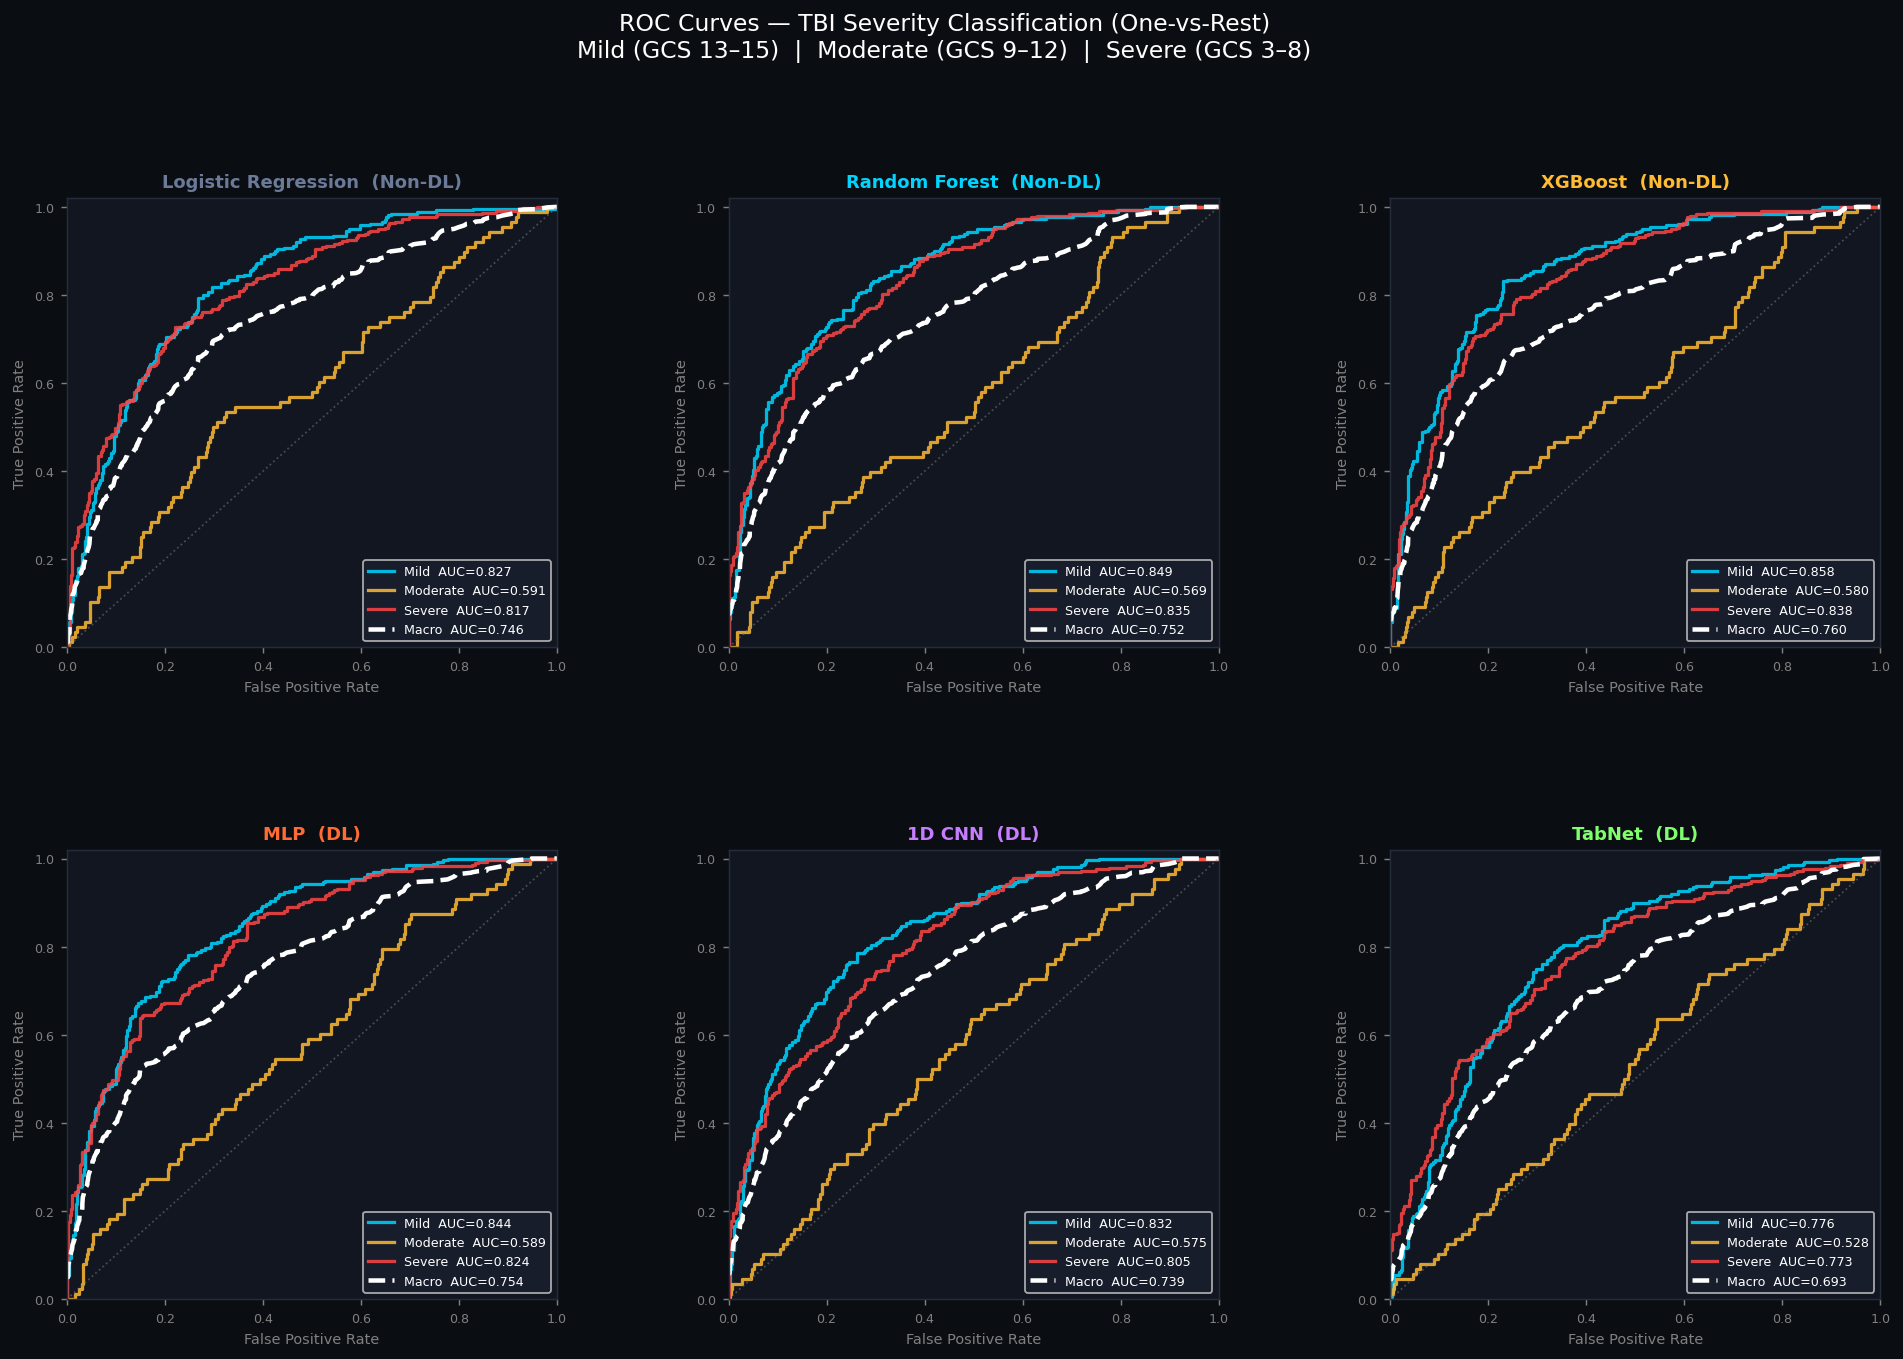

✓ Saved: roc_all_models_macro.png


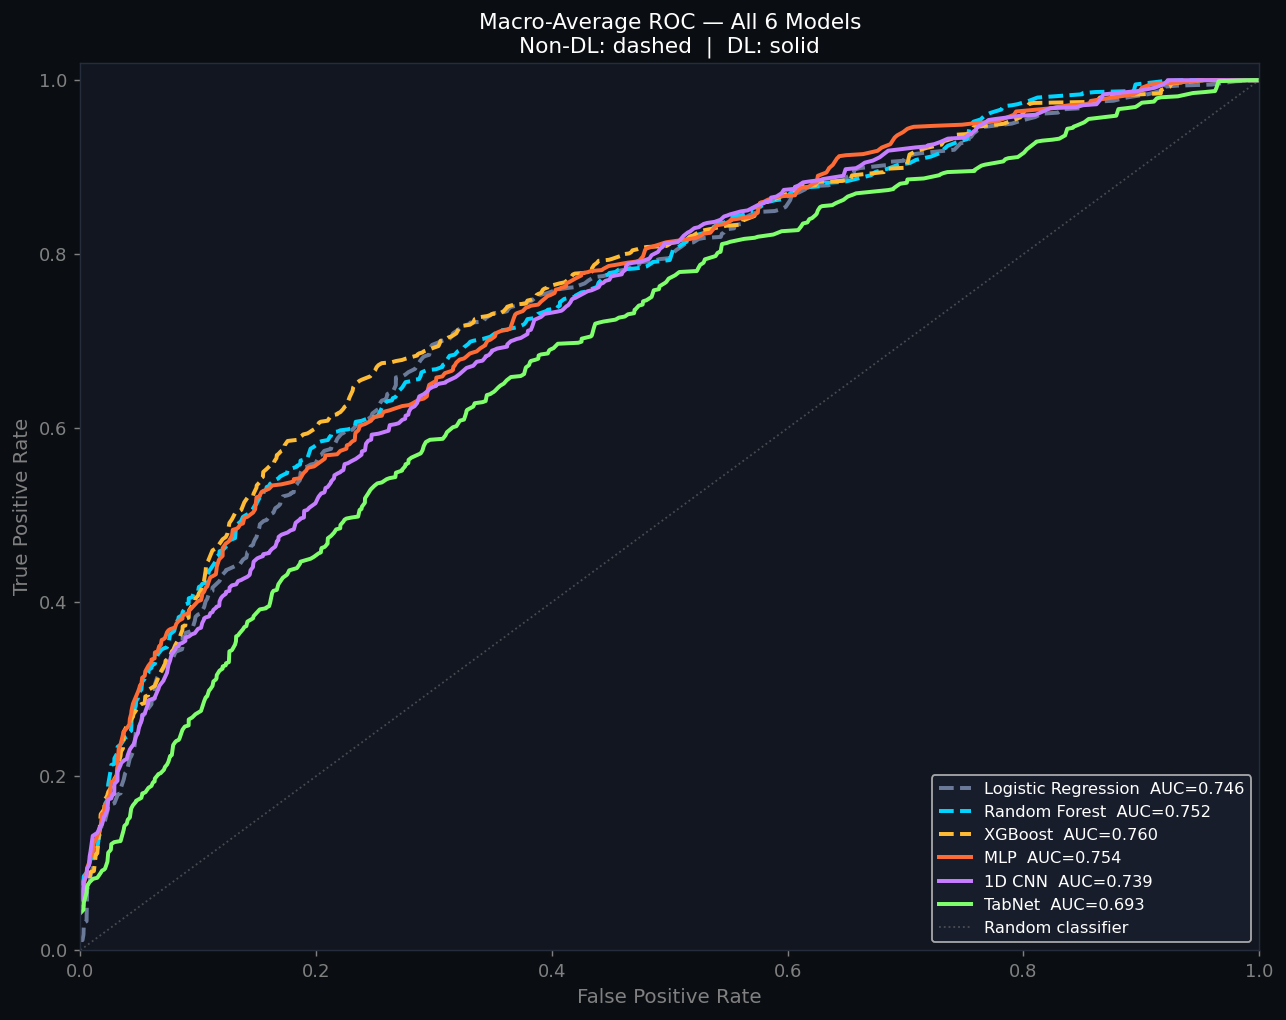

✓ Saved: roc_per_class_all_models.png


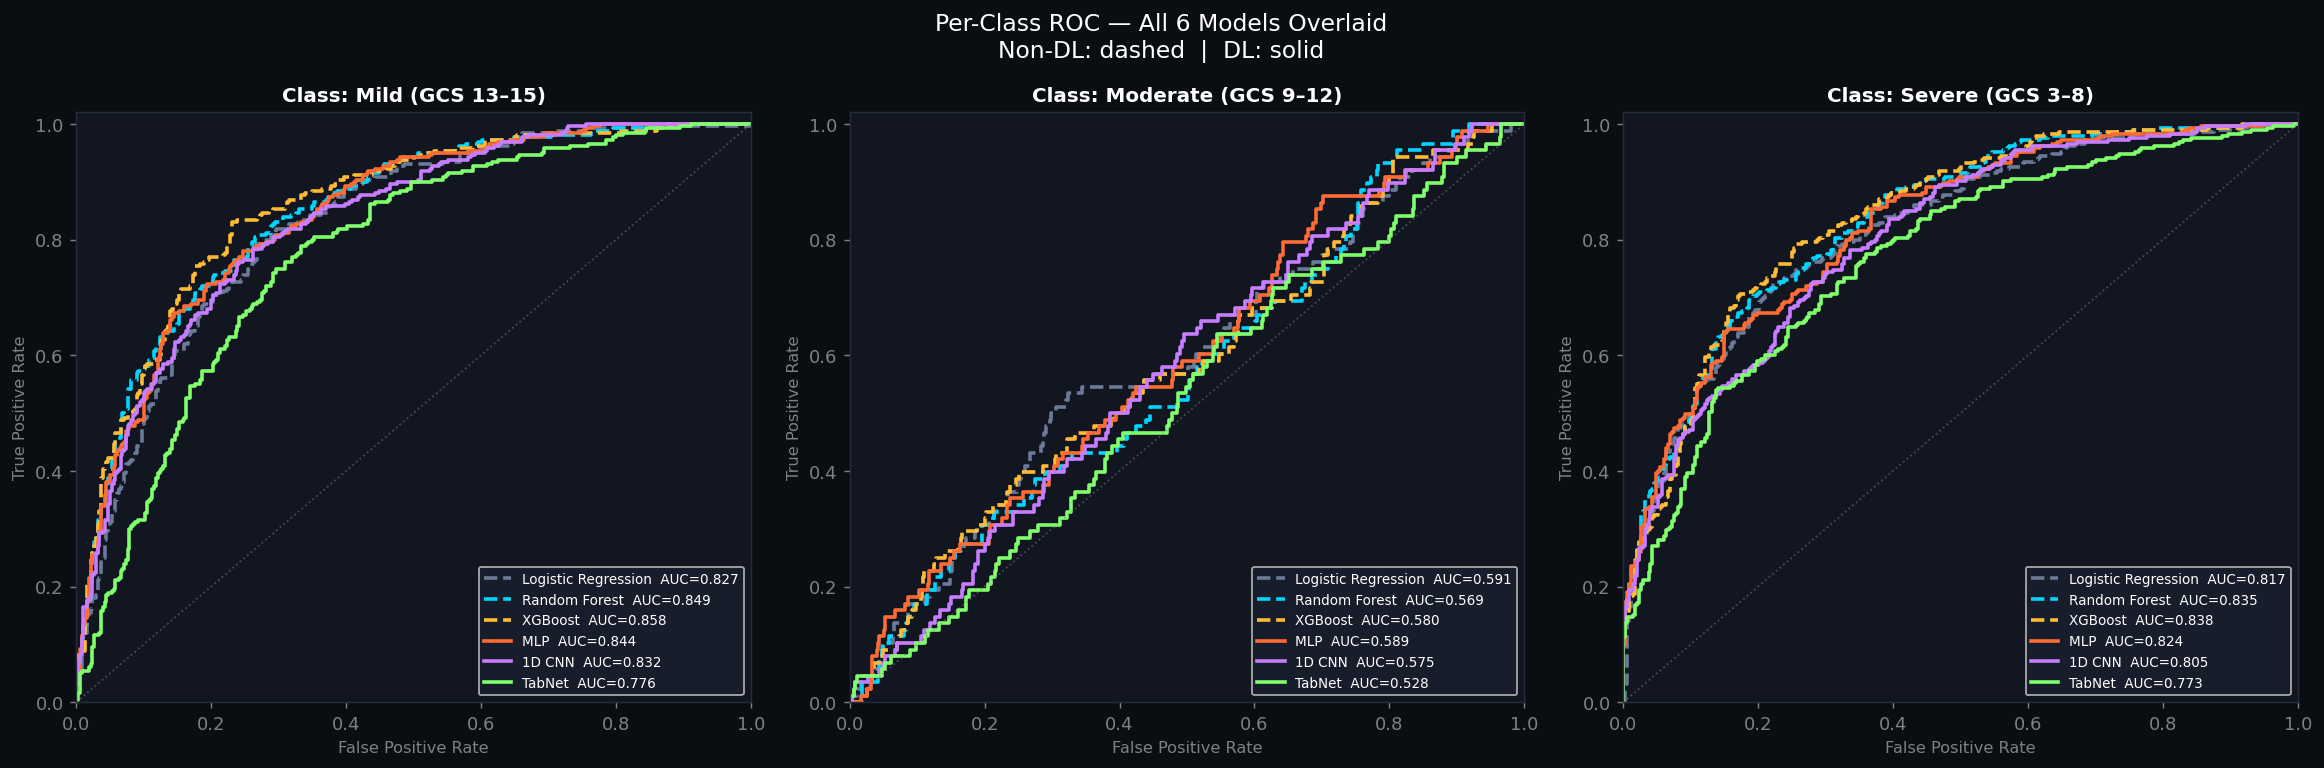


Model                        Mild   Moderate   Severe    Macro  Type
────────────────────────────────────────────────────────────────────
Logistic Regression        0.8273     0.5905   0.8174   0.7464  Non-DL
Random Forest              0.8495     0.5688   0.8351   0.7525  Non-DL
XGBoost                    0.8578     0.5796   0.8382   0.7599  Non-DL
MLP                        0.8437     0.5891   0.8236   0.7535  DL    
1D CNN                     0.8322     0.5753   0.8054   0.7389  DL    
TabNet                     0.7761     0.5278   0.7726   0.6935  DL    

ROC output files:
  roc_individual_models.png   — 2×3 grid: per-class + macro per model
  roc_all_models_macro.png    — all 6 macro curves overlaid (use in paper)
  roc_per_class_all_models.png — 3 panels: one per class, all models

Note: Moderate class typically has lowest AUC — boundary zone between
Mild and Severe makes it hardest to distinguish from both directions.



In [2]:
# ────────────────────────────────────────────────────────────
# CELL 13 — ROC Curves (3 plots)
# ────────────────────────────────────────────────────────────
# Plot 1: 2×3 grid — each model gets its own panel with
#         per-class (Mild/Moderate/Severe) + macro ROC curves
# Plot 2: All 6 macro ROC curves on one axis (paper figure)
# Plot 3: Per-class panels — all 6 models overlaid per class
from sklearn.metrics import roc_curve, auc
print("\n" + "=" * 60)
print("STEP 8 — ROC Curves")
print("=" * 60)

import matplotlib.gridspec as gridspec
from sklearn.preprocessing import label_binarize

CLASS_NAMES_ROC  = ["Mild", "Moderate", "Severe"]
CLASS_COLORS_ROC = ["#00d4ff", "#ffbb33", "#ff4444"]

def compute_roc_ovr(y_true, y_probs, n_classes=3):
    """One-vs-Rest ROC + macro average for multiclass."""
    y_bin = label_binarize(y_true, classes=list(range(n_classes)))
    fpr, tpr, roc_auc_dict = {}, {}, {}
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], y_probs[:, i])
        roc_auc_dict[i]    = auc(fpr[i], tpr[i])
    # Macro average
    all_fpr  = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(n_classes):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
    mean_tpr              /= n_classes
    fpr["macro"]           = all_fpr
    tpr["macro"]           = mean_tpr
    roc_auc_dict["macro"]  = auc(all_fpr, mean_tpr)
    return fpr, tpr, roc_auc_dict

# ── Plot 1: Individual 2×3 grid ──────────────────────────────
fig = plt.figure(figsize=(18, 11))
fig.patch.set_facecolor("#0a0d12")
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

for idx, (model_name, res) in enumerate(all_results.items()):
    ax  = fig.add_subplot(gs[idx // 3, idx % 3])
    fpr, tpr, roc_auc_d = compute_roc_ovr(y_test, res["probs"])

    for i, (cname, ccolor) in enumerate(
            zip(CLASS_NAMES_ROC, CLASS_COLORS_ROC)):
        ax.plot(fpr[i], tpr[i], color=ccolor, lw=1.8, alpha=0.85,
                label=f"{cname}  AUC={roc_auc_d[i]:.3f}")

    ax.plot(fpr["macro"], tpr["macro"], color="white", lw=2.5,
            linestyle="--",
            label=f"Macro  AUC={roc_auc_d['macro']:.3f}")
    ax.plot([0, 1], [0, 1], color="gray", lw=1,
            linestyle=":", alpha=0.5)

    mtype = "Non-DL" if model_name in non_dl_models else "DL"
    ax.set_title(f"{model_name}  ({mtype})",
                 color=MODEL_COLORS[model_name],
                 fontsize=10, fontweight="bold")
    ax.set_xlabel("False Positive Rate", color="gray", fontsize=8)
    ax.set_ylabel("True Positive Rate",  color="gray", fontsize=8)
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
    ax.set_facecolor("#111620")
    ax.tick_params(colors="gray", labelsize=7)
    ax.spines[:].set_color("#252d3d")
    ax.legend(facecolor="#1a2030", labelcolor="white",
               fontsize=7, loc="lower right")

fig.suptitle(
    "ROC Curves — TBI Severity Classification (One-vs-Rest)\n"
    "Mild (GCS 13–15)  |  Moderate (GCS 9–12)  |  Severe (GCS 3–8)",
    color="white", fontsize=13, y=1.01
)
plt.savefig("roc_individual_models.png", dpi=130,
            bbox_inches="tight", facecolor="#0a0d12")
plt.close()
print("✓ Saved: roc_individual_models.png")
display(Image(filename="roc_individual_models.png"))

# ── Plot 2: All models — macro AUC overlay ───────────────────
fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor("#0a0d12")
ax.set_facecolor("#111620")

for model_name, res in all_results.items():
    fpr, tpr, roc_auc_d = compute_roc_ovr(y_test, res["probs"])
    ls = "--" if model_name in non_dl_models else "-"
    ax.plot(fpr["macro"], tpr["macro"],
            color=MODEL_COLORS[model_name], lw=2.2, linestyle=ls,
            label=f"{model_name}  AUC={roc_auc_d['macro']:.3f}")

ax.plot([0, 1], [0, 1], color="gray", lw=1,
        linestyle=":", alpha=0.5, label="Random classifier")
ax.set_xlabel("False Positive Rate", color="gray", fontsize=11)
ax.set_ylabel("True Positive Rate",  color="gray", fontsize=11)
ax.set_title("Macro-Average ROC — All 6 Models\nNon-DL: dashed  |  DL: solid",
             color="white", fontsize=12)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
ax.tick_params(colors="gray")
ax.spines[:].set_color("#252d3d")
ax.legend(facecolor="#1a2030", labelcolor="white",
           fontsize=9, loc="lower right")
plt.tight_layout()
plt.savefig("roc_all_models_macro.png", dpi=130,
            bbox_inches="tight", facecolor="#0a0d12")
plt.close()
print("✓ Saved: roc_all_models_macro.png")
display(Image(filename="roc_all_models_macro.png"))

# ── Plot 3: Per-class — all models overlaid ──────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor("#0a0d12")

for ci, (cname, ctitle) in enumerate(zip(
        CLASS_NAMES_ROC,
        ["Mild (GCS 13–15)", "Moderate (GCS 9–12)", "Severe (GCS 3–8)"])):
    ax = axes[ci]
    ax.set_facecolor("#111620")
    for model_name, res in all_results.items():
        fpr, tpr, roc_auc_d = compute_roc_ovr(y_test, res["probs"])
        ls = "--" if model_name in non_dl_models else "-"
        ax.plot(fpr[ci], tpr[ci],
                color=MODEL_COLORS[model_name], lw=2, linestyle=ls,
                label=f"{model_name}  AUC={roc_auc_d[ci]:.3f}")
    ax.plot([0, 1], [0, 1], color="gray", lw=1,
            linestyle=":", alpha=0.5)
    ax.set_title(f"Class: {ctitle}", color="white",
                 fontsize=11, fontweight="bold")
    ax.set_xlabel("False Positive Rate", color="gray", fontsize=9)
    ax.set_ylabel("True Positive Rate",  color="gray", fontsize=9)
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
    ax.tick_params(colors="gray")
    ax.spines[:].set_color("#252d3d")
    ax.legend(facecolor="#1a2030", labelcolor="white",
               fontsize=7.5, loc="lower right")

fig.suptitle("Per-Class ROC — All 6 Models Overlaid\n"
             "Non-DL: dashed  |  DL: solid",
             color="white", fontsize=13)
plt.tight_layout()
plt.savefig("roc_per_class_all_models.png", dpi=130,
            bbox_inches="tight", facecolor="#0a0d12")
plt.close()
print("✓ Saved: roc_per_class_all_models.png")
display(Image(filename="roc_per_class_all_models.png"))

# ── AUC summary table ─────────────────────────────────────────
print(f"\n{'Model':<24} {'Mild':>8} {'Moderate':>10} "
      f"{'Severe':>8} {'Macro':>8}  Type")
print("─" * 68)
for model_name, res in all_results.items():
    fpr, tpr, roc_auc_d = compute_roc_ovr(y_test, res["probs"])
    mtype = "Non-DL" if model_name in non_dl_models else "DL    "
    print(f"{model_name:<24} {roc_auc_d[0]:>8.4f} {roc_auc_d[1]:>10.4f} "
          f"{roc_auc_d[2]:>8.4f} {roc_auc_d['macro']:>8.4f}  {mtype}")

print("""
ROC output files:
  roc_individual_models.png   — 2×3 grid: per-class + macro per model
  roc_all_models_macro.png    — all 6 macro curves overlaid (use in paper)
  roc_per_class_all_models.png — 3 panels: one per class, all models

Note: Moderate class typically has lowest AUC — boundary zone between
Mild and Severe makes it hardest to distinguish from both directions.
""")